# Predição de ativos da bolsa de valores

# Importa as bibliotecas

In [156]:
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
from pmdarima.arima import auto_arima # biblioteca que importa o arima
import pmdarima.arima as pm # biblioteca que importa o arima
import statsmodels
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import pandas as pd

from pandas_datareader import data 
import yfinance as yfin
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


In [157]:
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras

## Análise e visualização de ativos

### Carrega Dados

In [158]:
import yfinance as yf
import pandas as pd

yf.pdr_override()

cryptos=['BTC','ETH','SOL','ADA','TRX','FET','INJ']
peso_cryptos=np.ones(len(cryptos))*1/len(cryptos)

# adc o .SA no nome de cada ação para carregar no banco de dados
for i in range(np.size(cryptos)):
    cryptos[i]=cryptos[i]+"-USD"

cryptos_df = pd.DataFrame() 
for acao in cryptos:
     # Utilize o parâmetro 'interval' para especificar o intervalo de tempo
     cryptos_df[acao] = yf.download(acao, start='2017-01-01', interval='1d')['Close']

# substitui o .SA do nome de cada ação para visualização dos dados
for i in range(np.size(cryptos)):
    cryptos_df = cryptos_df.rename(columns={cryptos[i]:cryptos[i].replace('-USD', '')})

# Verifica como está o shape do dataframe
cryptos_df.shape

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


(2911, 7)

In [159]:
cryptos_df

,BTC,ETH,SOL,ADA,TRX,FET,INJ
Date,,,,,,,
2017-01-01,998.325012,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-02,1021.750000,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-03,1043.839966,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-04,1154.729980,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-05,1013.380005,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-12-16,106029.718750,3987.480957,216.334961,1.078856,0.296709,1.713254,28.511131
2024-12-17,106140.601562,3886.766113,222.816727,1.051525,0.279304,1.609964,26.879719
2024-12-18,100041.539062,3618.791260,206.381744,0.968420,0.257979,1.438311,24.479509


<Axes: ylabel='Date'>

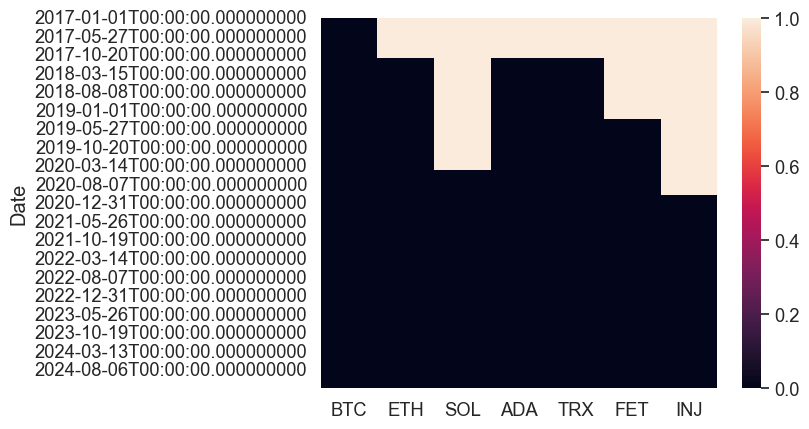

In [160]:
sns.heatmap(cryptos_df.isnull())

In [161]:
#apaga registros nulos
cryptos_df.dropna(inplace=True)
cryptos_df.to_csv('acoes.csv')
cryptos_df

,BTC,ETH,SOL,ADA,TRX,FET,INJ
Date,,,,,,,
2020-10-21,12823.689453,392.189972,1.890378,0.106187,0.026721,0.045765,0.773266
2020-10-22,12965.891602,413.772980,1.955653,0.110572,0.027042,0.049113,0.789443
2020-10-23,12931.539062,409.766693,1.960035,0.108083,0.026691,0.053041,1.183961
2020-10-24,13108.062500,412.457611,1.911828,0.108075,0.027050,0.056407,0.965414
2020-10-25,13031.173828,406.217773,1.787459,0.106351,0.026935,0.051211,0.901291
...,...,...,...,...,...,...,...
2024-12-16,106029.718750,3987.480957,216.334961,1.078856,0.296709,1.713254,28.511131
2024-12-17,106140.601562,3886.766113,222.816727,1.051525,0.279304,1.609964,26.879719
2024-12-18,100041.539062,3618.791260,206.381744,0.968420,0.257979,1.438311,24.479509


### Visualização dos dados 

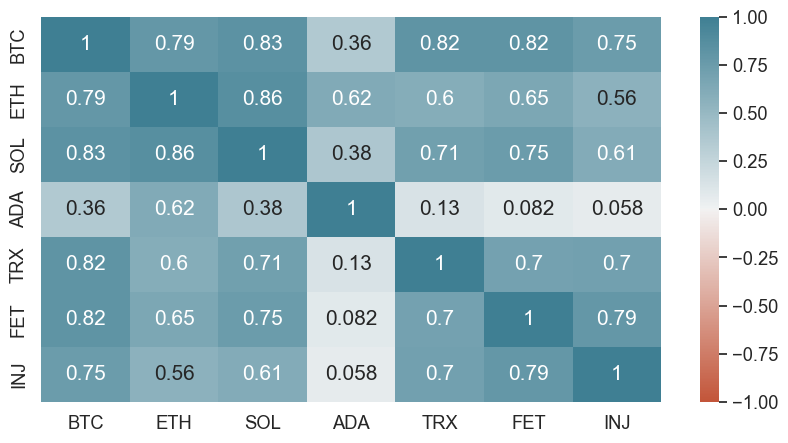

In [162]:
fig, axes = plt.subplots(1, 1, figsize=(10,5))

columns=cryptos_df.columns
corrmat = cryptos_df[columns].corr()
mask= np.zeros_like(corrmat)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corrmat,
            vmax=1, vmin=-1,
            annot=True, annot_kws={'fontsize':15},
            cmap=sns.diverging_palette(20,220,as_cmap=True))
plt.show()

In [163]:
cryptos_df.iloc[0].values

array([1.28236895e+04, 3.92189972e+02, 1.89037800e+00, 1.06187001e-01,
       2.67210007e-02, 4.57650013e-02, 7.73266017e-01])

In [164]:
# Normaliza os dados
cryptos_df_normalized = cryptos_df / cryptos_df.iloc[0].values

In [165]:
cryptos_df_normalized

,BTC,ETH,SOL,ADA,TRX,FET,INJ
Date,,,,,,,
2020-10-21,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2020-10-22,1.011089,1.055032,1.034530,1.041295,1.012013,1.073156,1.020920
2020-10-23,1.008410,1.044817,1.036848,1.017855,0.998877,1.158986,1.531117
2020-10-24,1.022176,1.051678,1.011347,1.017780,1.012312,1.232536,1.248489
2020-10-25,1.016180,1.035768,0.945556,1.001544,1.008009,1.118999,1.165564
...,...,...,...,...,...,...,...
2024-12-16,8.268269,10.167218,114.440054,10.159963,11.103963,37.435899,36.871052
2024-12-17,8.276916,9.910417,117.868874,9.902577,10.452602,35.178935,34.761283
2024-12-18,7.801307,9.227139,109.174855,9.119949,9.654541,31.428186,31.657294


In [166]:
#%% Carregando dados
cryptos_df=pd.read_csv('acoes.csv')
cryptos_df['Date']=pd.to_datetime(cryptos_df['Date'])
cryptos_df=cryptos_df.set_index('Date')
for col in cryptos_df.columns:
    cryptos_df[col]=cryptos_df[col].astype('float32')

In [167]:
cryptos_df_normalized = cryptos_df / cryptos_df.iloc[0].values

In [168]:
# Cria um gráfico de linha usando o Plotly
fig = go.Figure()
for cryptos in cryptos_df.columns:
#fig.add_trace(go.Scatter(x=cryptos_df.index, y=cryptos_df['IBOV'], mode='lines', name='Preço do Ibovespa'))
#fig.add_trace(go.Scatter(x=cryptos_df.index, y=cryptos_df['B3SA3'], mode='lines', name='Preço do B3SA3'))
    fig.add_trace(go.Scatter(x=cryptos_df_normalized.index, y=cryptos_df_normalized[cryptos], mode='lines', name=f'Preço do {cryptos}'))

# Configura o layout do gráfico
fig.update_layout(
    title='Preço do Ibovespa e ações',
    xaxis_title='Data',
    yaxis_title='Preço',
    showlegend=True
)

# Exibe o gráfico
fig.show()

## Indicadores de tendência e Séries Temporais 

Os swing traders geralmente utilizam médias móveis exponenciais (EMAs) de diferentes períodos para identificar tendências e sinais de compra e venda. As EMAs mais utilizadas pelos swing traders incluem:

-EMA de 9 períodos: A EMA de 9 períodos é comumente usada para identificar sinais de curto prazo e capturar movimentos rápidos do mercado. Pode fornecer sinais mais sensíveis e frequentes.

-EMA de 20 períodos: A EMA de 20 períodos é amplamente utilizada e considerada uma média móvel de curto prazo. É usada para identificar a direção da tendência de curto prazo e possíveis pontos de reversão.

-EMA de 50 períodos: A EMA de 50 períodos é frequentemente usada para identificar a direção da tendência de médio prazo. É uma média móvel amplamente observada pelos swing traders.

-EMA de 100 períodos: A EMA de 100 períodos é usada para identificar a direção da tendência de médio a longo prazo. É útil para identificar pontos de entrada e saída em operações de swing trading mais prolongadas.

-EMA de 200 períodos: A EMA de 200 períodos é uma das médias móveis mais amplamente observadas e é usada para identificar a direção da tendência de longo prazo. É frequentemente usada como um indicador-chave para determinar a tendência geral do mercado.

In [169]:
import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import data 
import datetime
import plotly.graph_objects as go

# Define o código de ticker da crypto
ticker = "BTC"


ticker=ticker+"-USD"

# Obtém os dados históricos da crypto
df = data.DataReader(ticker, start='2013-01-01')


[*********************100%%**********************]  1 of 1 completed


In [170]:
df.iloc[-10:,:]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-12-11,96656.062500,101913.359375,95747.226562,101173.031250,101173.031250,85391409936
2024-12-12,101167.804688,102524.914062,99339.953125,100043.000000,100043.000000,72073983533
2024-12-13,100046.648438,101888.804688,99233.281250,101459.257812,101459.257812,56894751583
2024-12-14,101451.437500,102618.882812,100634.054688,101372.968750,101372.968750,40422968793
2024-12-15,101373.531250,105047.539062,101227.031250,104298.695312,104298.695312,51145914137
2024-12-16,104293.578125,107780.578125,103322.984375,106029.718750,106029.718750,91020417816
2024-12-17,106030.687500,108268.445312,105291.734375,106140.601562,106140.601562,68589364868
2024-12-18,106147.296875,106470.609375,100041.539062,100041.539062,100041.539062,93865656139
2024-12-19,100070.687500,102748.148438,95587.679688,97490.953125,97490.953125,97221662392


In [171]:
scaler = MinMaxScaler()
y=scaler.fit_transform(df['Close'].values.reshape(-1,1))

# Function to compute Simple Moving Average (SMA)b
def calculate_sma(data, window):
    return data['Close'].rolling(window=window).mean()

# Function to compute Relative Strength Index (RSI)
def calculate_rsi(data, window):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Function to compute Moving Average Convergence Divergence (MACD)
def calculate_macd(data, short_window, long_window, signal_window):
    short_ema = data['Close'].ewm(span=short_window, min_periods=1, adjust=False).mean()
    long_ema = data['Close'].ewm(span=long_window, min_periods=1, adjust=False).mean()
    macd_line = short_ema - long_ema
    signal_line = macd_line.ewm(span=signal_window, min_periods=1, adjust=False).mean()
    return macd_line, signal_line

def calculate_bollinger_bands(data, window=20, num_std=2):
    sma = data['Close'].rolling(window=window).mean()
    std = data['Close'].rolling(window=window).std()
    upper_band = sma + num_std * std
    lower_band = sma - num_std * std
    return upper_band, lower_band

df['upper_band_bollinger'],df['lower_band_bollinger']=calculate_bollinger_bands(df)
# Calcula as EMAs de 9 e 20 períodos
df['EMA9'] = df['Close'].ewm(span=9).mean()
df['EMA20'] = df['Close'].ewm(span=20).mean()
df['EMA50'] = df['Close'].ewm(span=50).mean()
df['EMA100'] = df['Close'].ewm(span=100).mean()
df['EMA200'] = df['Close'].ewm(span=200).mean()
df['MA111'] = df['Close'].rolling(window=111).mean()
df['MA350'] = df['Close'].rolling(window=350).mean() 
df['MA111*2'] = df['Close'].rolling(window=111).mean() * 2
df['MA350*2'] = df['Close'].rolling(window=350).mean() * 2


# Calculate RSI (14-period)
df['RSI_14'] = calculate_rsi(df, window=14)

# Calculate MACD (12, 26, 9)
df['MACD'], df['Signal'] = calculate_macd(df, short_window=12, long_window=26, signal_window=9)


In [172]:
# Cria um gráfico de candlestick usando o Plotly
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                name='Candlestick')])

# Adiciona as médias móveis ao gráfico
fig.add_trace(go.Scatter(x=df.index, y=df['EMA9'], mode='lines', name='EMA9'))
fig.add_trace(go.Scatter(x=df.index, y=df['EMA20'], mode='lines', name='EMA20'))
fig.add_trace(go.Scatter(x=df.index, y=df['EMA50'], mode='lines', name='EMA50'))
fig.add_trace(go.Scatter(x=df.index, y=df['EMA100'], mode='lines', name='EMA100'))
fig.add_trace(go.Scatter(x=df.index, y=df['EMA200'], mode='lines', name='EMA200'))
fig.add_trace(go.Scatter(x=df.index, y=df['MA111'], mode='lines', name='MA111'))
fig.add_trace(go.Scatter(x=df.index, y=df['MA350'], mode='lines', name='MA350'))
fig.add_trace(go.Scatter(x=df.index, y=df['MA111*2'], mode='lines', name='MA111*2'))
fig.add_trace(go.Scatter(x=df.index, y=df['MA350*2'], mode='lines', name='MA350*2'))

fig.add_trace(go.Scatter(x=df.index, y=df['upper_band_bollinger'], mode='lines', name='upper band bollinger'))
fig.add_trace(go.Scatter(x=df.index, y=df['lower_band_bollinger'], mode='lines', name='lower band bollinger'))

if ticker=="^BVSP":
    ticker='IBOV'

# Configura o layout do gráfico
fig.update_layout(
    width=1500,
    height=700,
    title=f"Gráfico de Candlestick e Médias Móveis para {ticker}",
    xaxis_title="Data",
    yaxis_title="Preço",
    showlegend=True
)

# Exibe o gráfico
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


In [173]:
# Cria um gráfico de candlestick usando o Plotly
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                name='Candlestick')])

# Adiciona as médias móveis ao gráfico
fig.add_trace(go.Scatter(x=df.index, y=df['upper_band_bollinger'], mode='lines', name='upper band bollinger'))
fig.add_trace(go.Scatter(x=df.index, y=df['lower_band_bollinger'], mode='lines', name='lower band bollinger'))


# Configura o layout do gráfico
fig.update_layout(
    width=1500,
    height=700,
    title=f"Gráfico de Candlestick e Médias Móveis para {ticker}",
    xaxis_title="Data",
    yaxis_title="Preço",
    showlegend=True
)
fig.update_layout(xaxis_rangeslider_visible=False)

# Exibe o gráfico
fig.show()


In [174]:
def backtest(close_price_list, labels, initial_capital=10000, verbose=0):
    """
    Backtests a trading strategy based on buy/sell signals.

    Args:
        close_price_list: A list of closing prices for each period.
        labels: A list of trading signals ("BUY", "SELL", or "HOLD").
        initial_capital: The initial capital for the backtest.
        verbose: An integer controlling verbosity: 0 (no output), 1 (prints buy/sell actions), 2 (prints all actions and portfolio value).

    Returns:
        A list of portfolio values at each period.
    """
    cash = initial_capital  # Dinheiro em caixa
    shares = 0  # Quantidade de ações
    portfolio_values = []  # Histórico do valor total do portfólio
    
    for i, label in enumerate(labels):
        price = close_price_list[i]
        
        if label == "BUY" and cash >= price:
            shares_to_buy = cash // price
            shares += shares_to_buy
            cash -= shares_to_buy * price
            if verbose >= 1:
                print(f"BUY: Comprado {shares_to_buy} ações a R$ {price:.2f}")

        elif label == "SELL" and shares > 0:
            cash += shares * price
            shares = 0
            if verbose >= 1:
                print(f"SELL: Vendido {shares} ações a R$ {price:.2f}")

        # Valor atual do portfólio
        portfolio_value = cash + shares * price
        portfolio_values.append(portfolio_value)
        if verbose >= 2:
            print(f"Periodo {i+1}: Portfólio = R$ {portfolio_value:.2f}")

    # Resultado final
    final_value = cash + shares * close_price_list[-1]
    if verbose >= 1:
        print(f"Valor final do portfólio: R$ {final_value:.2f}")
        print(f"Retorno total: {((final_value - initial_capital) / initial_capital) * 100:.2f}%")

    return portfolio_values


In [175]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from ProcessingPipeline import FeaturesDataGenerator
features_dg=FeaturesDataGenerator()
# Dados de exemplo
close_price_list = df['Close'].values

#labels = labelling_method(close_price_list, 60)
label_data = features_dg.label_data(close_prices=df['Close'], window= 16)

labels=[("BUY" if np.allclose(label, [0, 1, 0]) else "SELL" if np.allclose(label, [0, 0, 1]) else "HOLD") 
        for label in label_data]# Realizar o backtest

print(np.unique(labels, return_counts=True))
# Realizar o backtest
portfolio_values = backtest(close_price_list, labels, initial_capital=100)

# Gráfico do desempenho
import plotly.graph_objects as go

#fig = go.Figure()

fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                name='Candlestick')])

# Valor do portfólio
#fig.add_trace(go.Scatter(
#    x=df.index,
#    y=portfolio_values,
#    mode='lines',
#    name='Valor do Portfólio'
#))

# Configuração do layout
fig.update_layout(
    title="Backtest de Estratégia de BUY, SELL, HOLD",
    xaxis_title="Data",
    yaxis_title="Valor",
    showlegend=False,
    width=1700,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)  # Margem esquerda, direita, superior e inferior
)


# Adiciona os marcadores BUY, SELL e HOLD
for i, label in enumerate(labels):
    if label == "BUY":
        fig.add_trace(go.Scatter(
            x=[df.index[i]],
            y=[df['Close'].iloc[i]- 0.03*df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='green', size=10, symbol='triangle-up'),
            name='BUY'
        ))
    elif label == "SELL":
        fig.add_trace(go.Scatter(
            x=[df.index[i]],
            y=[df['Close'].iloc[i]+ 0.03*df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='red', size=10, symbol='triangle-down'),
            name='SELL'
        ))
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

self.pred_days 1
input data shape (19, 1, 28)
output data shape (19, 3)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:88: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:96: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

invalid value encountered in divide



(array(['BUY', 'HOLD', 'SELL'], dtype='<U4'), array([ 153, 3450,  145], dtype=int64))


In [176]:

# Calcular a variação percentual entre o preço de fechamento de um dia e o dia seguinte
df['Variation'] = ((df['Close'] - df['Close'].shift(+1)) / df['Close'])*100
#pred_data_df['Variacao'] = ((pred_data_df['pred']-pred_data_df['pred'].shift(+1)) / pred_data_df['pred'])*100


# Thresholds for variation classification
positive_threshold = 0.03
negative_threshold = -0.03

# Create a new column for classified variation
df['Classification'] = df['Variation'].apply(lambda x: 
                                            1 if x > positive_threshold else (
                                                -1 if x < negative_threshold else 0))

#df['week']=df.index.week
df['weekday']=df.index.weekday+1
df['day']=df.index.day
df['month']=df.index.month
df['quarter']=df.index.quarter

df=df.reset_index().fillna(0)
df


,Date,Open,High,Low,Close,Adj Close,Volume,upper_band_bollinger,lower_band_bollinger,EMA9,...,MA350*2,RSI_14,MACD,Signal,Variation,Classification,weekday,day,month,quarter
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,0.000000,0.000000,457.334015,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,3,17,9,3
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,0.000000,0.000000,439.059564,...,0.000000,0.000000,-2.624024,-0.524805,-7.749979,-1,4,18,9,3
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,0.000000,0.000000,420.918755,...,0.000000,0.000000,-7.014744,-1.822793,-7.508691,-1,5,19,9,3
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,0.000000,0.000000,416.848713,...,0.000000,0.000000,-9.249402,-3.308115,3.450199,1,6,20,9,3
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,0.000000,0.000000,411.485880,...,0.000000,0.000000,-11.699137,-4.986319,-2.528196,-1,7,21,9,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3743,2024-12-16,104293.578125,107780.578125,103322.984375,106029.718750,106029.718750,91020417816,104899.758645,93060.223386,101750.993998,...,129414.580759,69.495850,3707.914747,3675.381559,1.632583,1,1,16,12,4
3744,2024-12-17,106030.687500,108268.445312,105291.734375,106140.601562,106140.601562,68589364868,106033.429510,92944.359552,102628.915511,...,129764.195804,69.465422,3847.987439,3709.902735,0.104468,1,2,17,12,4
3745,2024-12-18,106147.296875,106470.609375,100041.539062,100041.539062,100041.539062,93865656139,106000.716227,93415.979867,102111.440221,...,130091.015022,52.166832,3427.344393,3653.391067,-6.096530,-1,3,18,12,4
3746,2024-12-19,100070.687500,102748.148438,95587.679688,97490.953125,97490.953125,97221662392,105999.988776,93419.650287,101187.342802,...,130395.649487,51.508181,2855.257152,3493.764284,-2.616228,-1,4,19,12,4


## Data preprocessing to stock forecast

In [177]:
del acao, axes, close_price_list, col, columns, corrmat, cryptos, cryptos_df, cryptos_df_normalized, fig, features_dg

In [178]:
import requests
import pandas as pd
import numpy as np

# Lista de criptomoedas
ticker='FET'
cryptos = [ticker]
ticker=ticker+"-USDT"

peso_cryptos = np.ones(len(cryptos)) * 1 / len(cryptos)

# Adiciona o par USD para cada cripto
cryptos = [crypto + "USDT" for crypto in cryptos]

# Função para baixar dados históricos da Binance API
def get_binance_data(symbol, interval='1d', start_time='2017-01-01'):
    base_url = "https://api.binance.com/api/v3/klines"
    end_time = int(pd.Timestamp.now().timestamp() * 1000)  # Data atual

    # Converte a data de início para timestamp
    start_timestamp = int(pd.Timestamp(start_time).timestamp() * 1000)

    # Lista para armazenar os dados
    data_list = []

    # Faça requisições iterativas até obter todos os dados
    while start_timestamp < end_time:
        params = {
            'symbol': symbol,
            'interval': interval,
            'startTime': start_timestamp,
            'endTime': start_timestamp + (1000 * 60 * 60 * 24 * 365),  # Intervalo de 1 ano
            'limit': 1000  # Máximo de registros por chamada
        }

        # Coleta dados da API
        response = requests.get(base_url, params=params)
        data = response.json()

        # Verifica se a resposta da API está vazia
        if not data:
            break

        # Converte os dados em DataFrame
        df = pd.DataFrame(data, columns=[
            'timestamp', 'open', 'high', 'low', 'close', 'volume',
            'close_time', 'quote_asset_volume', 'number_of_trades',
            'taker_buy_base', 'taker_buy_quote', 'ignore'
        ])

        # Verifica se o DataFrame está vazio
        if df.empty:
            break

        # Adiciona os dados à lista
        data_list.append(df)

        # Atualiza o start_timestamp para a próxima requisição
        if not df.empty:
            start_timestamp = int(df['timestamp'].iloc[-1]) + 1000  # Adiciona 1 segundo ao último timestamp
        else:
            break

    # Concatena todos os DataFrames
    if data_list:
        df = pd.concat(data_list, ignore_index=True)
    else:
        df = pd.DataFrame()

    # Formata e filtra os dados necessários
    if not df.empty:
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df.set_index('timestamp', inplace=True)
        df['close'] = df['close'].astype(float)
        df['low'] = df['low'].astype(float)
        df['high'] = df['high'].astype(float)
        df['open'] = df['open'].astype(float)
        df['volume'] = df['volume'].astype(float)
    return df


# Intervalos disponíveis
intervals = ['1m', '3m', '5m', '15m', '30m', '1h', '2h', '4h', '6h', '8h', '12h', '1d', '3d', '1w', '1M']

#choice = int(input("Escolha um intervalo (número): "))
#interval = intervals[choice - 1]
interval ='4h'

# Baixar e consolidar dados em um DataFrame
cryptos_df = pd.DataFrame()
for crypto in cryptos:
    data = get_binance_data(crypto, start_time='2019-01-01', interval=interval)
    # Ajusta o nome da coluna removendo "USDT" antes de adicionar ao DF
    #data.columns = [crypto.replace('USDT', '')]
    if cryptos_df.empty:
        cryptos_df = data
    else:
        cryptos_df = pd.concat([cryptos_df, data], axis=1)

if not cryptos_df.empty:
    cryptos_df = cryptos_df.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume',
    })
    # Visualização dos dados
    cryptos_df=cryptos_df.rename_axis('Date')
    print(cryptos_df.shape)
else:
    print("Nenhum dado encontrado para o símbolo e intervalo especificados.")

df=cryptos_df
df.reset_index(inplace= True)


(12728, 11)


### Pré-processamento dos dados para predição 

In [179]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from ProcessingPipeline import FeaturesDataGenerator, scrapingHistoricalData

In [180]:
SHD=scrapingHistoricalData()
df=SHD.get_crypto_historical_data(['BTC'], interval, '2015-01-01')

In [181]:
split_data=FeaturesDataGenerator().split_data

self.pred_days 1
input data shape (19, 1, 28)
output data shape (19, 3)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:88: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:96: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

invalid value encountered in divide



In [182]:
# separa os dados em Treino e Teste
split_data=FeaturesDataGenerator().split_data
X_train, X_val, T_train, T_val=split_data(df['Close'].values, df['Date'], factor=0.7)
X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.7)

print('Train data shape',X_train.shape)
print('Vall data shape',X_val.shape)
print('Test data shape',X_test.shape)


self.pred_days 1
input data shape (19, 1, 28)
output data shape (19, 3)
Train data shape (10375,)
Vall data shape (3113,)
Test data shape (1335,)


In [183]:
#features_indicators=FeaturesDataGenerator().features_name
#features_indicators=['Data_lookback','variations','EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200']
features_indicators=['Data_lookback', 'Volume',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200','MA111', 'MA350','MACD']

#features_indicators=['Data_lookback','EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200','MA111', 'MA350','MACD',]
features_indicators=['Data_lookback', 'Volume', 'Low', 'High', 'Open','EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200','MA111', 'MA350','MACD']




features_indicators=['Data_lookback', 'Open', 'High', 'Low', 'Volume', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',  'Chaikin_Money_Flow',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI','Williams_R',  'ROC',  'PPO', 'Chaikin_Money_Flow']

features_indicators=['Data_lookback', 'Open', 'High', 'Low', 'Volume']

features_indicators=[
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
                    'MA111', 'MA350', 
                    #'RSI_14',  
                    #'MACD', 'MACD_Signal', 'MACD_Histogram',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']
features_indicators=[ 'CCI','Williams_R',  'ROC',  'PPO', 'Chaikin_Money_Flow']


features_indicators=['Data_lookback', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',  'Chaikin_Money_Flow',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC',  'PPO', 'Chaikin_Money_Flow']#, 'Williams_R']

pred_days = int(24/4 * 2.5) 
buy_sell_threshold=[0.05,-0.05]
lookback = 24
batch_size = 16
shuffle = True

min_norm=-1
max_norm=1

X_data_gen_train = FeaturesDataGenerator(df[df['Date'].isin(T_train)].iloc[:,:], lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
X_data_gen_val = FeaturesDataGenerator(df[df['Date'].isin(T_val)].iloc[:,:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
X_data_gen_test = FeaturesDataGenerator(df[df['Date'].isin(T_test)].iloc[:,:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])

self.pred_days 15


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:780: RuntimeWarning:

divide by zero encountered in log



input data shape (10351, 24, 24)
output data shape (10351, 3)
self.pred_days 15
input data shape (3089, 24, 24)
output data shape (3089, 3)
self.pred_days 15
input data shape (1311, 24, 24)
output data shape (1311, 3)


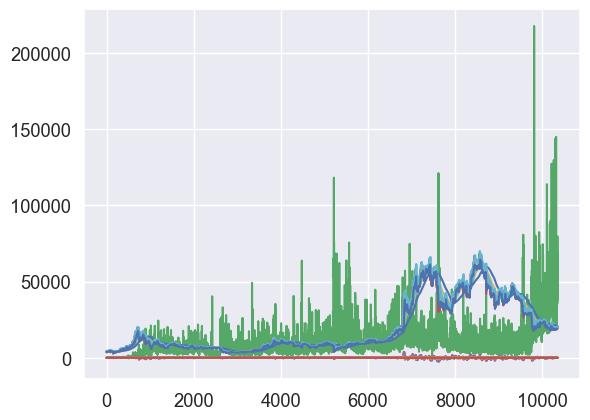

In [184]:
plt.plot(X_data_gen_train.features[:,-1, 0:])
plt.show()

In [185]:
# Dados de exemplo
data_idx = -500
input_data = X_data_gen_test.InputData['Close'].iloc[data_idx:].values
date = X_data_gen_test.InputData['Date'].iloc[data_idx:]
#labels = labelling_method(close_price_list, 60)

labels=[("BUY" if np.allclose(label, [0, 1, 0]) else "SELL" if np.allclose(label, [0, 0, 1]) else "HOLD") 
        for label in X_data_gen_test.y_classification]# Realizar o backtest


labels=labels[data_idx:]
print(np.unique(labels, return_counts=True))
#portfolio_values = backtest(input_data, labels, initial_capital=100000)

# Gráfico do desempenho
import plotly.graph_objects as go

#fig = go.Figure()

fig = go.Figure(data=[go.Candlestick(x=X_data_gen_test.InputData['Date'].iloc[data_idx:],
                open=X_data_gen_test.InputData['Open'].iloc[data_idx:],
                high=X_data_gen_test.InputData['High'].iloc[data_idx:],
                low=X_data_gen_test.InputData['Low'].iloc[data_idx:],
                close=X_data_gen_test.InputData['Close'].iloc[data_idx:],
                name='Candlestick')])

# Valor do portfólio
#fig.add_trace(go.Scatter(
#    x=X_data_gen_test.InputData['Date'],
#    y=portfolio_values,
#    mode='lines',
#    name='Valor do Portfólio'
#))

# Configuração do layout
fig.update_layout(
    title="Backtest de Estratégia de BUY, SELL, HOLD",
    xaxis_title="Data",
    yaxis_title="Valor",
    showlegend=False,
    width=1700,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)  # Margem esquerda, direita, superior e inferior
)


# Adiciona os marcadores BUY, SELL e HOLD
for i, label in enumerate(labels):
    if label == "BUY":
        fig.add_trace(go.Scatter(
            x=[date.iloc[i]],
            y=[input_data[i] - 0.05*input_data[i]],
            mode='markers',
            marker=dict(color='green', size=10, symbol='triangle-up'),
            name='BUY'
        ))
    elif label == "SELL":
        fig.add_trace(go.Scatter(
            x=[date.iloc[i]],
            y=[input_data[i] + 0.05*input_data[i]],
            mode='markers',
            marker=dict(color='yellow', size=10, symbol='triangle-down'),
            name='SELL'
        ))
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


(array(['BUY', 'HOLD', 'SELL'], dtype='<U4'), array([ 16, 464,  20], dtype=int64))


In [186]:
X_data_gen_train.features[:,:,:].shape

(10351, 24, 24)

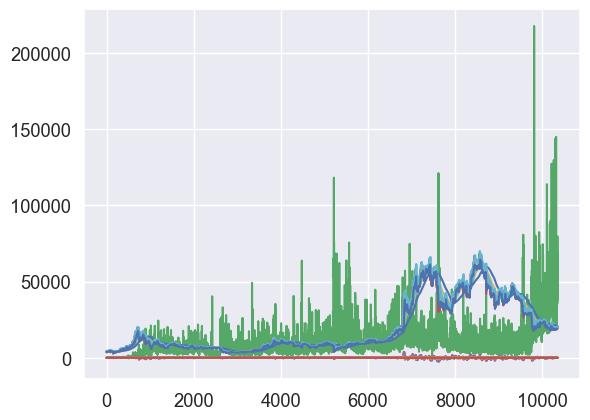

In [187]:
plt.plot(X_data_gen_train.features[:,-1, :])
plt.show()


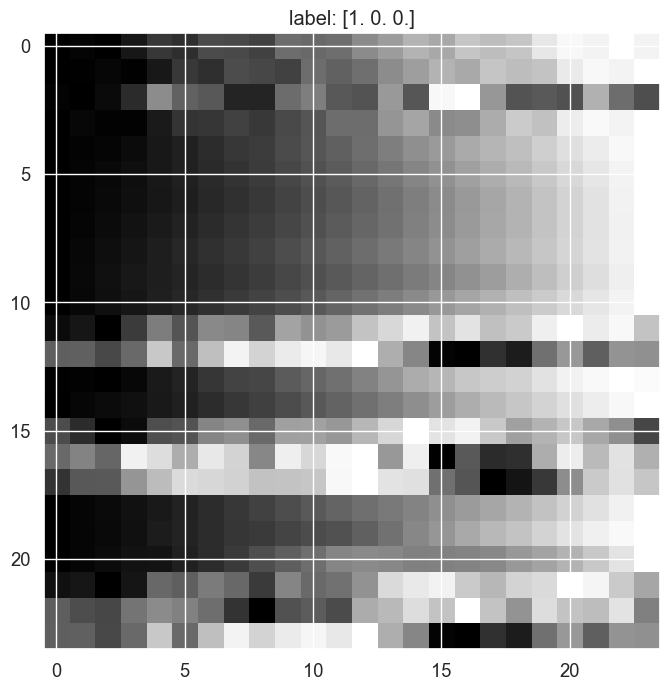

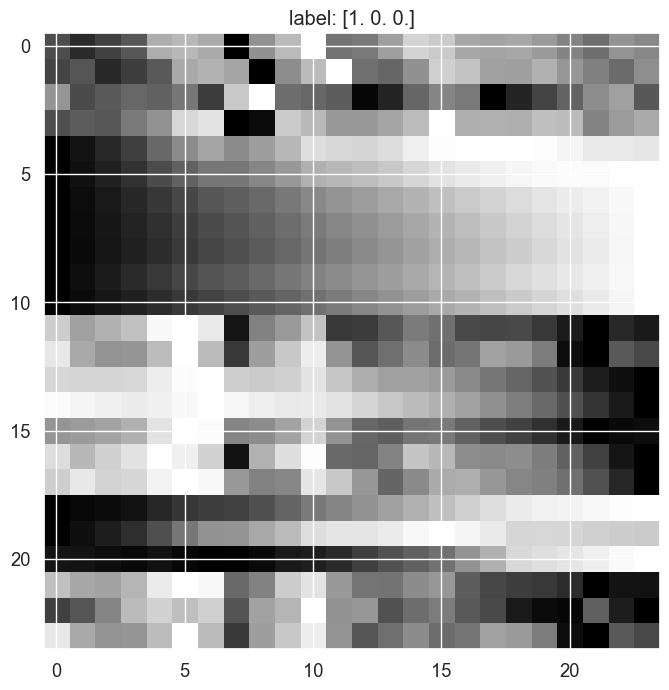

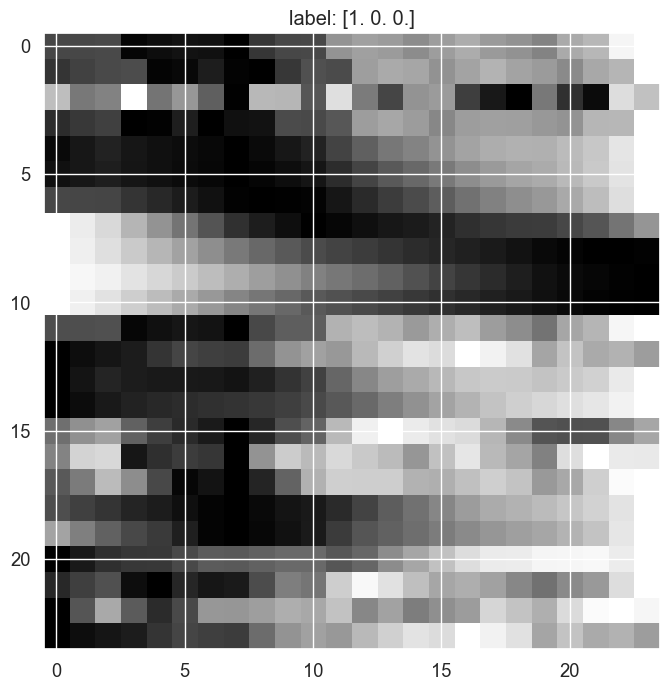

In [188]:
for idx, data_2d in enumerate(np.array(X_data_gen_train[15][0][:3])):
    plt.figure(figsize=(15,8))
    # Visualize the image
    plt.imshow(data_2d.T, cmap='gray', interpolation='nearest')
    plt.title('label: {}'.format(X_data_gen_train[15][1][idx]))

    #plt.colorbar()
    plt.show()

In [189]:
input_data= X_data_gen_test.InputData['Close'][lookback:].values.reshape(-1,1)
input_data.shape


(1311, 1)

In [190]:
np.diff(X_data_gen_test.InputData['Close'])[lookback-1:].shape

(1311,)

In [191]:
#aux_data=np.hstack([X_data_gen_test.variations.reshape(-1,1),X_data_gen_test.features[:,0].reshape(-1,1),X_data_gen_test.y_classification])
input_data= X_data_gen_test.InputData['Close'][lookback:].values.reshape(-1,1)
variations = np.diff(X_data_gen_test.InputData['Close'])[lookback-1:]

aux_data=np.hstack([variations.reshape(-1,1), input_data, X_data_gen_test.y_classification])

#recomentations_2=pd.DataFrame(data=aux_data,columns=['var','X', 'Hold','Buy','Strong_Buy','Sell','Strong_Sell'])
recomentations_2=pd.DataFrame(data=aux_data,columns=['var','X', 'Hold','Buy','Sell'])
recomentations_2.tail(20)    


,var,X,Hold,Buy,Sell
1291,-60.74,106805.75,1.0,0.0,0.0
1292,2.56,106808.31,1.0,0.0,0.0
1293,-329.84,106478.47,1.0,0.0,0.0
1294,-2.58,106475.89,1.0,0.0,0.0
1295,-342.15,106133.74,1.0,0.0,0.0
1296,-1369.76,104763.98,1.0,0.0,0.0
1297,-513.23,104250.75,1.0,0.0,0.0
1298,777.58,105028.33,1.0,0.0,0.0
1299,-599.79,104428.54,1.0,0.0,0.0
1300,-1610.72,102817.82,1.0,0.0,0.0


In [192]:
X_data_gen_test.InputData

,Date,Open,High,Low,Close,Volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base,taker_buy_quote,ignore
13486,2024-04-25 16:00:00,64135.93,64975.00,63971.48,64747.11,5893.40227,1714075199999,380272215.28188800,258832,2898.46699000,187006896.80651060,0
13487,2024-04-25 20:00:00,64747.12,65297.94,64447.75,64498.34,3788.26197,1714089599999,245387709.30347640,162094,1721.75085000,111524693.04753510,0
13488,2024-04-26 00:00:00,64498.33,64662.53,63890.82,64381.24,4501.10389,1714103999999,289506745.06788870,177517,2220.21052000,142796710.32579410,0
13489,2024-04-26 04:00:00,64381.25,64610.82,64000.02,64276.95,3820.59365,1714118399999,245849673.05723950,133609,1951.86258000,125599462.03587080,0
13490,2024-04-26 08:00:00,64276.94,64581.52,64059.80,64244.02,3562.57552,1714132799999,229115466.15545370,129315,1684.23961000,108323758.53188710,0
...,...,...,...,...,...,...,...,...,...,...,...,...
14816,2024-12-19 16:00:00,100679.86,101200.00,96251.32,97199.72,15856.49892,1734638399999,1562535484.51310640,1912854,7202.96105000,710483343.25712190,0
14817,2024-12-19 20:00:00,97199.72,98500.00,95700.00,97461.86,10508.99952,1734652799999,1020500437.92258250,1022809,5634.66045000,547557584.72971690,0
14818,2024-12-20 00:00:00,97461.86,97814.09,96000.00,97106.02,8712.02871,1734667199999,845260879.77287990,1302263,4046.38644000,392687732.41133680,0
14819,2024-12-20 04:00:00,97106.02,98233.00,96374.03,97832.53,6871.39877,1734681599999,669316617.70421950,1068862,3155.06098000,307393460.34563140,0


In [193]:
X_data_gen_test.InputData

,Date,Open,High,Low,Close,Volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base,taker_buy_quote,ignore
13486,2024-04-25 16:00:00,64135.93,64975.00,63971.48,64747.11,5893.40227,1714075199999,380272215.28188800,258832,2898.46699000,187006896.80651060,0
13487,2024-04-25 20:00:00,64747.12,65297.94,64447.75,64498.34,3788.26197,1714089599999,245387709.30347640,162094,1721.75085000,111524693.04753510,0
13488,2024-04-26 00:00:00,64498.33,64662.53,63890.82,64381.24,4501.10389,1714103999999,289506745.06788870,177517,2220.21052000,142796710.32579410,0
13489,2024-04-26 04:00:00,64381.25,64610.82,64000.02,64276.95,3820.59365,1714118399999,245849673.05723950,133609,1951.86258000,125599462.03587080,0
13490,2024-04-26 08:00:00,64276.94,64581.52,64059.80,64244.02,3562.57552,1714132799999,229115466.15545370,129315,1684.23961000,108323758.53188710,0
...,...,...,...,...,...,...,...,...,...,...,...,...
14816,2024-12-19 16:00:00,100679.86,101200.00,96251.32,97199.72,15856.49892,1734638399999,1562535484.51310640,1912854,7202.96105000,710483343.25712190,0
14817,2024-12-19 20:00:00,97199.72,98500.00,95700.00,97461.86,10508.99952,1734652799999,1020500437.92258250,1022809,5634.66045000,547557584.72971690,0
14818,2024-12-20 00:00:00,97461.86,97814.09,96000.00,97106.02,8712.02871,1734667199999,845260879.77287990,1302263,4046.38644000,392687732.41133680,0
14819,2024-12-20 04:00:00,97106.02,98233.00,96374.03,97832.53,6871.39877,1734681599999,669316617.70421950,1068862,3155.06098000,307393460.34563140,0


In [194]:
#recomentations_2=pd.DataFrame(data=np.hstack([np.roll(X_data_gen_train.variations.reshape(-1,1),1)[lookback:],X_data_gen_train.features[:,lookback-1].reshape(-1,1),X_data_gen_train.y_classification]),columns=['var','X', 'Hold','Buy','Sell'])
#recomentations_2.head(10)

In [195]:
'''variations = ((X_train - np.roll(X_train, 1)) / X_train) * 100
recomendations=pd.DataFrame(data=np.hstack([np.vstack([variations[lookback:-pred_days],X_train[lookback:-pred_days]]).T,X_data_gen_train.comput_outputs(X_train)]), columns=['var','X', 'Hold','Buy','Sell'])
recomendations.head(10)'''

"variations = ((X_train - np.roll(X_train, 1)) / X_train) * 100\nrecomendations=pd.DataFrame(data=np.hstack([np.vstack([variations[lookback:-pred_days],X_train[lookback:-pred_days]]).T,X_data_gen_train.comput_outputs(X_train)]), columns=['var','X', 'Hold','Buy','Sell'])\nrecomendations.head(10)"

###  Get imbalanced database 

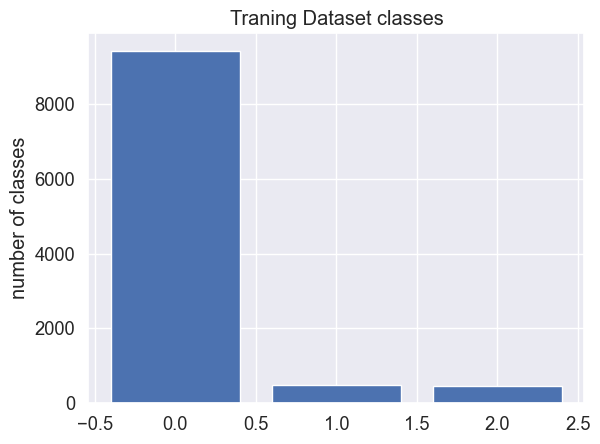

In [196]:
Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
classes, counts=np.unique(Y_train_categorical,return_counts=True) 

fig, ax = plt.subplots()
plt.bar(classes,counts)
ax.set_ylabel('number of classes')
ax.set_title('Traning Dataset classes')
plt.show()

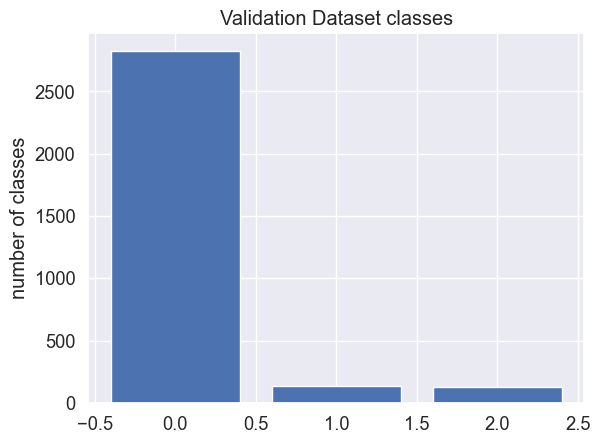

In [197]:
Y_val_categorical=np.argmax(X_data_gen_val.y_classification,axis=1)
classes, counts=np.unique(Y_val_categorical,return_counts=True) 

fig, ax = plt.subplots()
plt.bar(classes,counts)
ax.set_ylabel('number of classes')
ax.set_title('Validation Dataset classes')
plt.show()

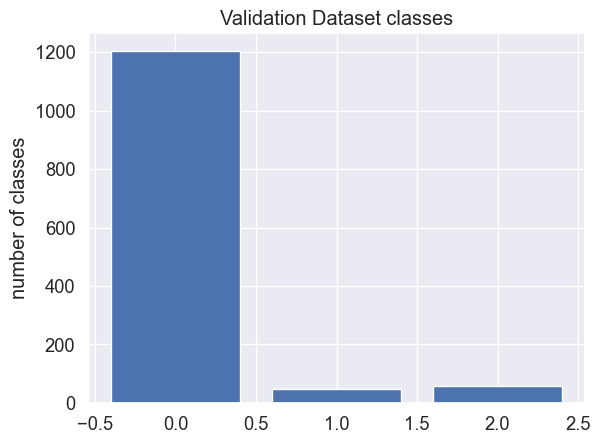

In [198]:
Y_test_categorical=np.argmax(X_data_gen_test.y_classification,axis=1)
classes, counts=np.unique(Y_test_categorical,return_counts=True) 

fig, ax = plt.subplots()
plt.bar(classes,counts)
ax.set_ylabel('number of classes')
ax.set_title('Validation Dataset classes')
plt.show()

In [199]:
from sklearn.utils import class_weight
n_classes, counts=np.unique(Y_train_categorical,return_counts=True) 

output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))
print(output_class_weights)
weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

[0.36573387 7.29457364 7.77102102]


## Neural Networkt aproach

In [200]:
X_data,y_data=X_data_gen_train[0]
n_classes=y_data.shape[1]
n_classes

3

### Models 1D

#### CNN_LSTM

In [201]:
# Model name
model_name = "CNN_LSTM_MultiHead"
#np.random.seed(42)

# Define CNN-LSTM feature extraction function
def CNN_LSTM(inputs):
  x = Conv1D(64, kernel_size=1, strides=1, activation='relu')(inputs)
  x = BatchNormalization()(x)
  x = MaxPooling1D(2)(x)
  x = Dropout(0.5)(x)
  return x

def CNN_bracnh(Features):
    x = Conv1D(64, kernel_size=1, strides=1, activation='relu')(Features)
    x = BatchNormalization()(x)
    x = MaxPooling1D(1)(x)
    x = Dropout(0.5)(x)
    x = Flatten()(x)
    return x
  
# Define a single function for both heads (regression and classification)
def head(features, n_outputs, activation, name= None):
  x = Dense(256)(features)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  output = Dense(n_outputs)(x)

  output = Activation(activation, name=name)(output)  # Dynamic output name

  return output

# Create the full model
input_shape = (X_data.shape[1],X_data.shape[2])  # Assuming your input shape
input_data = Input(shape=input_shape)

Features = CNN_LSTM(input_data)
#features_branch1=CNN_bracnh(Features)
features_branch2=CNN_bracnh(Features)
# Create separate heads with appropriate number of outputs and activations
#regression_output = head(features_branch1, n_outputs=pred_days, activation='linear',name='regression_head')
classification_output = head(features_branch2, n_outputs=n_classes, activation='softmax',name='classification_head')

# Create the model with two heads
model_CNN_LSTM = Model(inputs=input_data, outputs=[classification_output])
model_CNN_LSTM._name = model_name

# Print model summary
model_CNN_LSTM.summary()

Model: "CNN_LSTM_MultiHead"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 24, 24)]          0         
                                                                 
 conv1d_12 (Conv1D)          (None, 24, 64)            1600      
                                                                 
 batch_normalization_40 (Ba  (None, 24, 64)            256       
 tchNormalization)                                               
                                                                 
 max_pooling1d_12 (MaxPooli  (None, 12, 64)            0         
 ng1D)                                                           
                                                                 
 dropout_30 (Dropout)        (None, 12, 64)            0         
                                                                 
 conv1d_13 (Conv1D)          (None, 12, 64)     

In [202]:
X_data.shape

TensorShape([16, 24, 24])

In [203]:
# Model name
model_name = "CNN_MultiHead"
#np.random.seed(42)

def common_layers(input1):
        """Common layers to the network model

        Returns:
            Graph: the common layers model
        """

        ##################################################################
        # CNN architecture
        conv_layer = Conv1D(64, (3), padding="same")(input1)
        conv_layer = BatchNormalization()(conv_layer)
        conv_layer = Activation('relu')(conv_layer)
        conv_layer = MaxPooling1D(pool_size=(3), strides=1, padding="same")(conv_layer)
        conv_layer = Conv1D(128, (3), padding="same")(conv_layer)
        conv_layer = BatchNormalization()(conv_layer)
        conv_layer = Activation('relu')(conv_layer)
        conv_layer = MaxPooling1D(pool_size=(3), strides=2, padding="same")(conv_layer)
        
        ##################################################################

        return conv_layer

def head_layer(conv_layer, num_classes, activation='linear', output_name=None):
    
    head = Conv1D(64, (3), padding="same")(conv_layer)
    head = BatchNormalization()(head)
    head = Activation('relu')(head)
    head = MaxPooling1D(pool_size=(3), strides=2, padding="same")(head)

    head = Dropout(0.5)(head)
    head = Flatten()(head)

    x = Dense(256)(head)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x

# Create the full model
input_data = Input(shape=input_shape)

Features = common_layers(input_data)
# Create separate heads with appropriate number of outputs and activations
regression_output = head_layer(Features, num_classes=pred_days, activation='linear',output_name='regression_head')
classification_output = head_layer(Features, num_classes=n_classes, activation='softmax',output_name='classification_head')

# Create the model with two heads
model_CNN_MultiHead = Model(inputs=input_data, outputs=[classification_output])
model_CNN_MultiHead._name = model_name

# Print model summary
model_CNN_MultiHead.summary()

Model: "CNN_MultiHead"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_14 (InputLayer)       [(None, 24, 24)]          0         
                                                                 
 conv1d_14 (Conv1D)          (None, 24, 64)            4672      
                                                                 
 batch_normalization_43 (Ba  (None, 24, 64)            256       
 tchNormalization)                                               
                                                                 
 activation_37 (Activation)  (None, 24, 64)            0         
                                                                 
 max_pooling1d_14 (MaxPooli  (None, 24, 64)            0         
 ng1D)                                                           
                                                                 
 conv1d_15 (Conv1D)          (None, 24, 128)         

#### MultiLayer Perceptron

In [204]:
# Model name
model_name = "MLP"

# Input layer
input_shape = (X_data.shape[1],X_data.shape[2])  # Assuming your input shape
input_data = Input(shape=input_shape)

# Adicione uma camada de flatten
x = Flatten()(input_data)
# Dense layer 1 with batch normalization
x = Dense(64)(x)
x = BatchNormalization()(x)
activation1 = Activation('relu')(x)

#Dense layer 2 with batch normalization and dropout
x = Dense(32)(activation1)
x = BatchNormalization()(x)
activation2 = Activation('relu')(x)
x = Dropout(0.5)(activation2)


# Define a single function for both heads (regression and classification)
def head(features, n_outputs, activation='linear', name= None):
  """
  Defines a dense layer head for either regression or classification.

  Args:
      features: Input tensor from the feature extraction part.
      n_outputs: Number of outputs for the head.
      activation: Activation function for the output layer (defaults to 'linear' for regression).

  Returns:
      A Keras functional API model representing the head with its output.
  """
  
  x = Dense(32)(features)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  
  output = Dense(n_outputs)(x)
  output = Activation(activation, name=name)(output)  # Dynamic output name

  return output


# Create separate heads with appropriate number of outputs and activations
#regression_output = head(activation2, n_outputs=pred_days, activation='linear',name='regression_head')
classification_output = head(activation2, n_outputs=n_classes, activation='softmax',name='classification_head')

# Create the model
model_MLP = Model(inputs=input_data, outputs=[classification_output])
model_MLP._name = model_name

# Print model summary
model_MLP.summary()


Model: "MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_15 (InputLayer)       [(None, 24, 24)]          0         
                                                                 
 flatten_11 (Flatten)        (None, 576)               0         
                                                                 
 dense_58 (Dense)            (None, 64)                36928     
                                                                 
 batch_normalization_51 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 activation_45 (Activation)  (None, 64)                0         
                                                                 
 dense_59 (Dense)            (None, 32)                2080      
                                                               

In [205]:
model_name = "simple_MLP"
input_shape = (X_data.shape[1],X_data.shape[2])  # Assuming your input shape

model_simple_MLP = Sequential([
    Dense(64, activation='relu', input_shape=input_shape),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model_simple_MLP._name = model_name
model_simple_MLP.summary()

Model: "simple_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_62 (Dense)            (None, 24, 64)            1600      
                                                                 
 dense_63 (Dense)            (None, 24, 32)            2080      
                                                                 
 dense_64 (Dense)            (None, 24, 3)             99        
                                                                 
Total params: 3779 (14.76 KB)
Trainable params: 3779 (14.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Long Short-Term Memory (LSTM) 

In [206]:
model_name= "LSTM"
# Camada de entrada
input_shape = (X_data.shape[1],X_data.shape[2])  # Assuming your input shape
input_data = Input(shape=input_shape)

# Camada LSTM
lstm_output  = LSTM(64, return_sequences=True)(input_data)
bn_lstm = BatchNormalization()(lstm_output)
activation_lstm = Activation('relu')(bn_lstm)
Dropout_output = Dropout(0.5)(activation_lstm)

lstm_output2  = LSTM(64, activation='relu', return_sequences=False)(Dropout_output)
Dropout_output = Dropout(0.5)(lstm_output2)

#lstm_output3  = LSTM(64, activation='relu', return_sequences=True)(Dropout_output)
#Dropout_output = Dropout(0.1)(lstm_output3)

#lstm_output  = LSTM(4, activation='tanh')(Dropout_output)
#Dropout_output = Dropout(0.5)(lstm_output)

dense_output = Dense(32, activation='relu')(Dropout_output)
Dropout_output=Dropout(0.5)(dense_output)

#dense_output = Dense(8, activation='relu')(Dropout_output)
#Dropout_output=Dropout(0.5)(dense_output)
# Camada de saída
output = Dense(n_classes, activation='softmax')(Dropout_output)

model_LSTM = Model(inputs=input_data, outputs=output)
model_LSTM._name = model_name
model_LSTM.summary()

Model: "LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 24, 24)]          0         
                                                                 
 lstm_6 (LSTM)               (None, 24, 64)            22784     
                                                                 
 batch_normalization_54 (Ba  (None, 24, 64)            256       
 tchNormalization)                                               
                                                                 
 activation_48 (Activation)  (None, 24, 64)            0         
                                                                 
 dropout_39 (Dropout)        (None, 24, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 64)                33024     
                                                              

#### Long Short-Term Memory (GRU) 

In [207]:
model_name= "GRU"
# Camada de entrada
input_shape = (X_data.shape[1],X_data.shape[2])  # Assuming your input shape
input_data = Input(shape=input_shape)
# Camada LSTM
GRU_output  = GRU(64)(input_data)

bn_lstm = BatchNormalization()(GRU_output)
activation_lstm = Activation('relu')(bn_lstm)
Dropout_output = Dropout(0.5)(activation_lstm)

output = Dense(n_classes, activation='softmax')(Dropout_output)

model_GRU = Model(inputs=input_data, outputs=output)
model_GRU._name = model_name
model_GRU.summary()

Model: "GRU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 24, 24)]          0         
                                                                 
 gru_2 (GRU)                 (None, 64)                17280     
                                                                 
 batch_normalization_55 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 activation_49 (Activation)  (None, 64)                0         
                                                                 
 dropout_42 (Dropout)        (None, 64)                0         
                                                                 
 dense_67 (Dense)            (None, 3)                 195       
                                                               

#### LSTM with Attention layer

In [208]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="Attention_")
class Attention_(tf.keras.layers.Layer):
    def __init__(self, units,  **kwargs):
        super(Attention_, self).__init__( **kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def build(self, input_shape):
        self.W.build(input_shape)
        self.V.build(input_shape)

    def call(self, inputs):
        # Compute attention scores
        score = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=-1)

        # Apply attention weights to input
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=-1)

        return context_vector

    @classmethod
    def from_config(cls, config):
        return cls(**config)


In [209]:
X_data.shape

TensorShape([16, 24, 24])

In [210]:
model_name= "LSTM_AT"
# Camada de entrada
input_shape = (X_data.shape[1],X_data.shape[2])  # Assuming your input shape
input_data = Input(shape=input_shape)

# Dense layer 1 with batch normalization
x = Dense(64)(input_data)
x = BatchNormalization()(x)
x = Activation('relu')(x)

#Dense layer 2 with batch normalization and dropout
x = Dense(32)(x)
x = BatchNormalization()(x)
X = Activation('relu')(x)
x = Dropout(0.5)(x)
x = Dense(32)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

LSTM_output = tf.keras.layers.LSTM(64, return_sequences=True)(x)

bn_lstm = BatchNormalization()(LSTM_output)
activation_lstm = Activation('relu')(bn_lstm)
X = Dropout(0.5)(activation_lstm)

x = Attention_(64)(X)

x = tf.keras.layers.Dense(n_classes,activation='softmax')(x)

model_LSTM_AT = tf.keras.Model(inputs=input_data, outputs=x)
model_LSTM_AT._name = model_name

model_LSTM_AT.summary()

Model: "LSTM_AT"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_18 (InputLayer)       [(None, 24, 24)]          0         
                                                                 
 dense_68 (Dense)            (None, 24, 64)            1600      
                                                                 
 batch_normalization_56 (Ba  (None, 24, 64)            256       
 tchNormalization)                                               
                                                                 
 activation_50 (Activation)  (None, 24, 64)            0         
                                                                 
 dense_69 (Dense)            (None, 24, 32)            2080      
                                                                 
 batch_normalization_57 (Ba  (None, 24, 32)            128       
 tchNormalization)                                         

### Models 2D

In [211]:
'''
def CNN_model():
    model = Sequential()
    model.add(Conv2D (32,5,5, padding='same', input_shape=(1,5, 4), activation='relu')) 
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dense (200, activation='relu'))
    model.add(Dropout (0.2))
    model.add(Flatten())
    model.add(Dense (200, activation=' relu'))
    model.add(Dense (3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model
    '''

"\ndef CNN_model():\n    model = Sequential()\n    model.add(Conv2D (32,5,5, padding='same', input_shape=(1,5, 4), activation='relu')) \n    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))\n    model.add(Dense (200, activation='relu'))\n    model.add(Dropout (0.2))\n    model.add(Flatten())\n    model.add(Dense (200, activation=' relu'))\n    model.add(Dense (3, activation='softmax'))\n    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])\n    return model\n    "

### Hyperparams and trainnig

**Metrics and Loss Functions**  

In [212]:
from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

**Optimizers**  

In [213]:
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    return optimizer1
    #

**Train options callbacks**  

In [214]:
# Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

# verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)


checkpoint_filepath = './models_checkpoint/'
checkpoint_filepath =f'models/{model_name}_{ticker}_{lookback}_ex1'


def checkpoints(model_name):
    checkpoint_filepath =f'models/model_{model_name}_stock_{ticker}_lookback_{lookback}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback

### Models train

In [215]:
#ategorical_accuracy =tf.keras.metrics.categorical_accuracy
#loss =tf.keras.losses.categorical_crossentropy
loss = weighted_categorical_crossentropy_loss
#loss = tf.keras.losses.MAE

Training model : models/model_MLP_stock_FET-USDT_lookback_24
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: MLP
Epoch 1/200

Epoch 1: val_loss improved from inf to 1.06652, saving model to models\model_MLP_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_MLP_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_MLP_stock_FET-USDT_lookback_24\assets


646/646 - 15s - loss: 0.4093 - accuracy: 0.7448 - matthews_correlation_coefficient: 0.5978 - val_loss: 1.0665 - val_accuracy: 0.7529 - val_matthews_correlation_coefficient: 0.6363 - lr: 0.0010 - 15s/epoch - 23ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 1.06652
646/646 - 10s - loss: 0.1924 - accuracy: 0.8844 - matthews_correlation_coefficient: 0.8238 - val_loss: 2.2702 - val_accuracy: 0.7688 - val_matthews_correlation_coefficient: 0.6532 - lr: 0.0010 - 10s/epoch - 16ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 1.06652
646/646 - 8s - loss: 0.1310 - accuracy: 0.9283 - matthews_correlation_coefficient: 0.8918 - val_loss: 1.9575 - val_accuracy: 0.7940 - val_matthews_correlation_coefficient: 0.6924 - lr: 0.0010 - 8s/epoch - 12ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 1.06652
646/646 - 7s - loss: 0.0864 - accuracy: 0.9529 - matthews_correlation_coefficient: 0.9299 - val_loss: 2.3368 - val_accuracy: 0.7879 - val_matthews_correlation_coefficient:

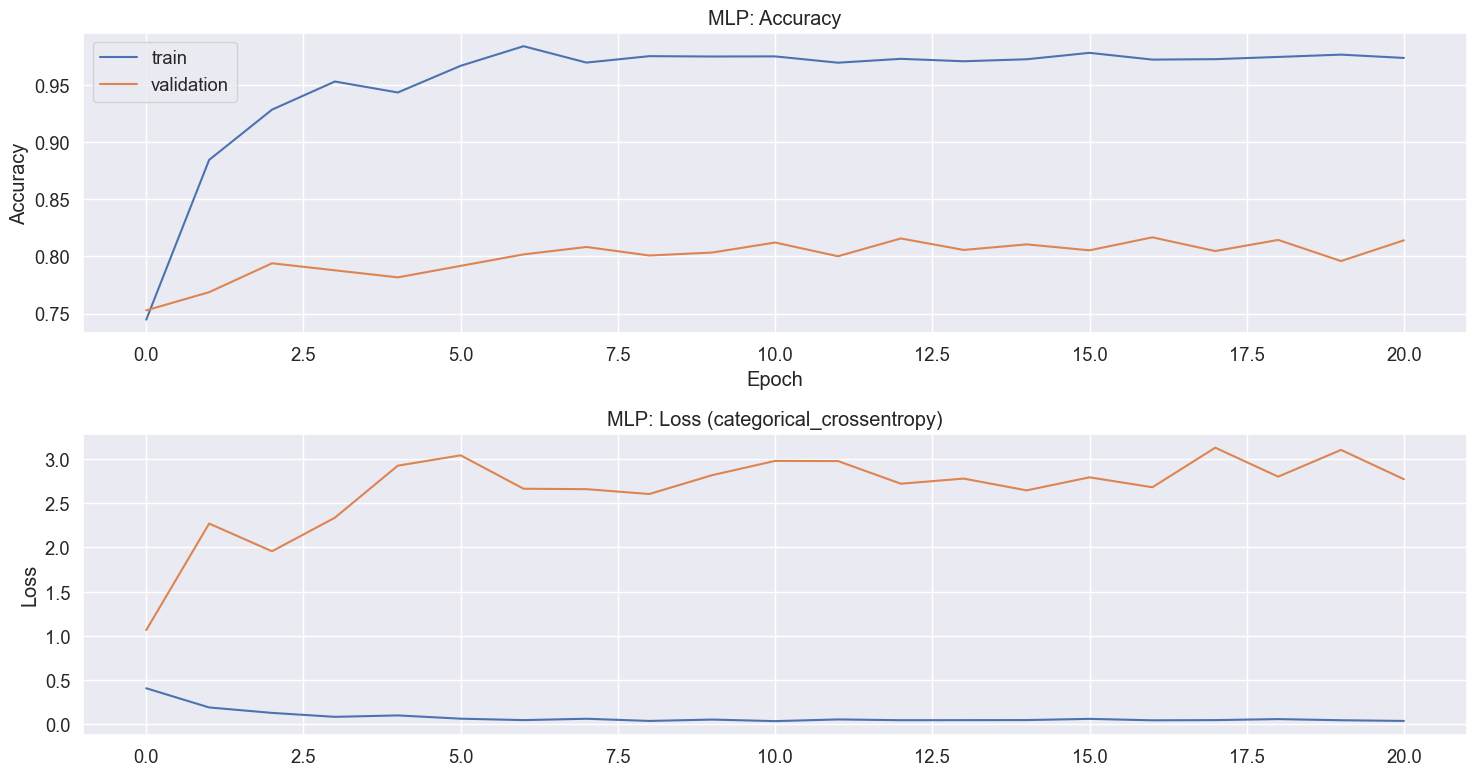

Training model : models/model_GRU_stock_FET-USDT_lookback_24
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: GRU
Epoch 1/200

Epoch 1: val_loss improved from inf to 0.63298, saving model to models\model_GRU_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_GRU_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_GRU_stock_FET-USDT_lookback_24\assets


646/646 - 33s - loss: 0.7369 - accuracy: 0.4895 - matthews_correlation_coefficient: 0.2221 - val_loss: 0.6330 - val_accuracy: 0.4106 - val_matthews_correlation_coefficient: 0.0822 - lr: 0.0010 - 33s/epoch - 50ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.63298 to 0.61573, saving model to models\model_GRU_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_GRU_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_GRU_stock_FET-USDT_lookback_24\assets


646/646 - 19s - loss: 0.5169 - accuracy: 0.6012 - matthews_correlation_coefficient: 0.3886 - val_loss: 0.6157 - val_accuracy: 0.5091 - val_matthews_correlation_coefficient: 0.2246 - lr: 0.0010 - 19s/epoch - 30ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 0.61573
646/646 - 17s - loss: 0.3766 - accuracy: 0.7043 - matthews_correlation_coefficient: 0.5487 - val_loss: 0.6441 - val_accuracy: 0.6839 - val_matthews_correlation_coefficient: 0.5259 - lr: 0.0010 - 17s/epoch - 26ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 0.61573
646/646 - 11s - loss: 0.3000 - accuracy: 0.7728 - matthews_correlation_coefficient: 0.6568 - val_loss: 0.7743 - val_accuracy: 0.6684 - val_matthews_correlation_coefficient: 0.5026 - lr: 0.0010 - 11s/epoch - 16ms/step
Epoch 5/200

Epoch 5: val_loss did not improve from 0.61573
646/646 - 12s - loss: 0.2455 - accuracy: 0.8195 - matthews_correlation_coefficient: 0.7279 - val_loss: 0.9849 - val_accuracy: 0.7562 - val_matthews_correlation_coefficie

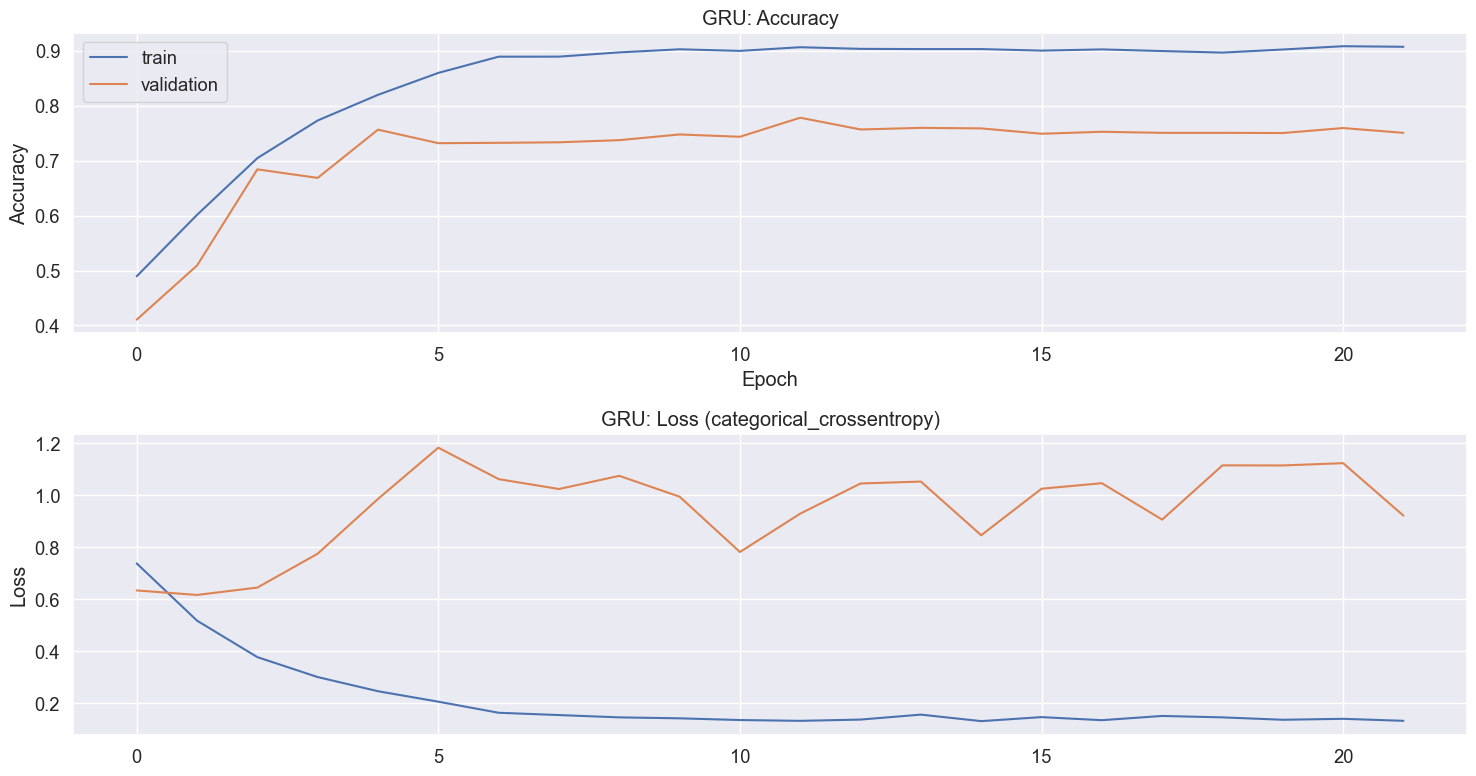

Training model : models/model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_LSTM_MultiHead
Epoch 1/200

Epoch 1: val_loss improved from inf to 0.83366, saving model to models\model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24\assets


646/646 - 21s - loss: 0.7163 - accuracy: 0.5687 - matthews_correlation_coefficient: 0.3483 - val_loss: 0.8337 - val_accuracy: 0.3063 - val_matthews_correlation_coefficient: -5.2681e-02 - lr: 0.0010 - 21s/epoch - 32ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.83366 to 0.82903, saving model to models\model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_CNN_LSTM_MultiHead_stock_FET-USDT_lookback_24\assets


646/646 - 17s - loss: 0.4385 - accuracy: 0.6777 - matthews_correlation_coefficient: 0.5131 - val_loss: 0.8290 - val_accuracy: 0.3724 - val_matthews_correlation_coefficient: 0.0641 - lr: 0.0010 - 17s/epoch - 26ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 0.82903
646/646 - 10s - loss: 0.3516 - accuracy: 0.7518 - matthews_correlation_coefficient: 0.6247 - val_loss: 0.9365 - val_accuracy: 0.5282 - val_matthews_correlation_coefficient: 0.2890 - lr: 0.0010 - 10s/epoch - 16ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 0.82903
646/646 - 18s - loss: 0.2857 - accuracy: 0.8023 - matthews_correlation_coefficient: 0.7029 - val_loss: 1.2511 - val_accuracy: 0.5155 - val_matthews_correlation_coefficient: 0.2707 - lr: 0.0010 - 18s/epoch - 27ms/step
Epoch 5/200

Epoch 5: val_loss did not improve from 0.82903
646/646 - 10s - loss: 0.2478 - accuracy: 0.8289 - matthews_correlation_coefficient: 0.7428 - val_loss: 1.1204 - val_accuracy: 0.5774 - val_matthews_correlation_coefficie

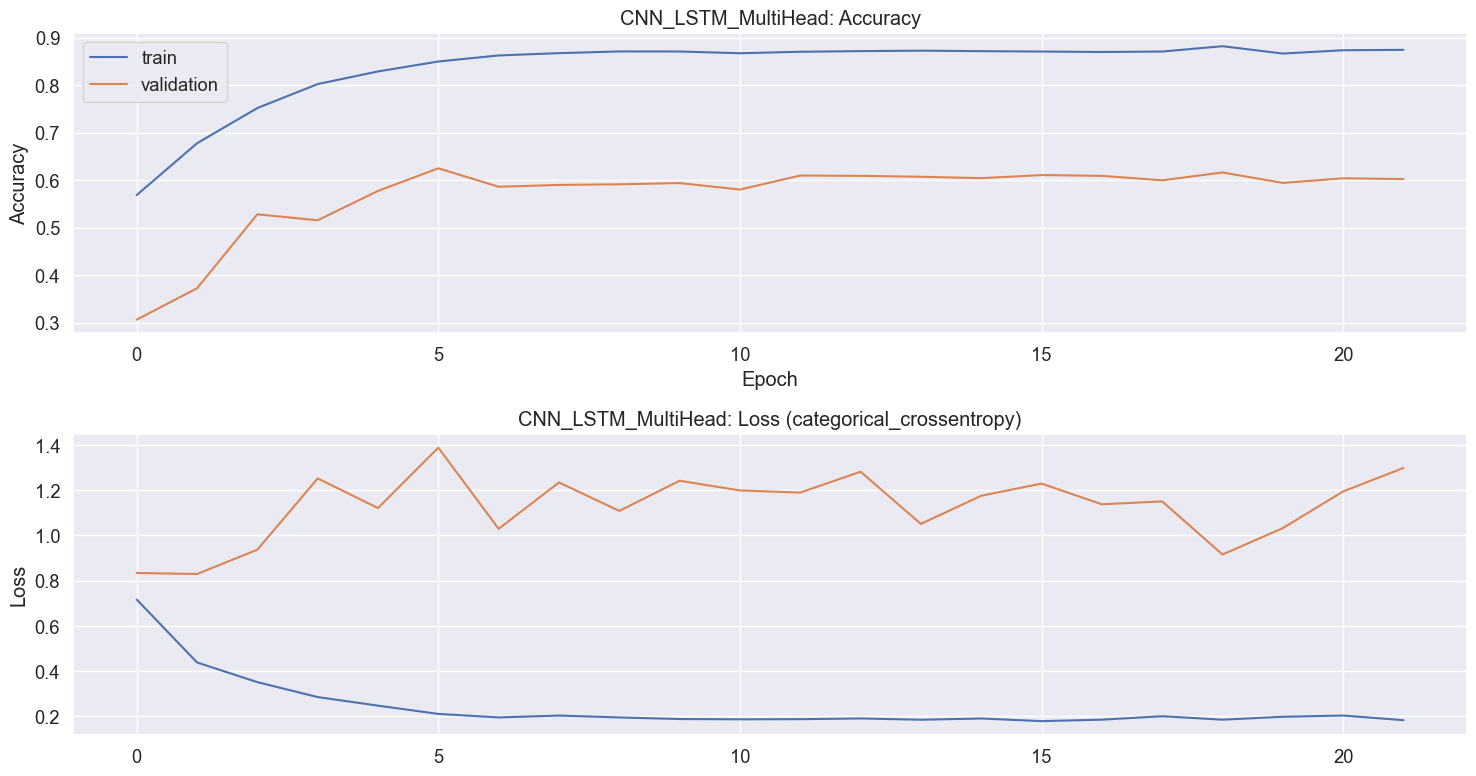

Training model : models/model_CNN_MultiHead_stock_FET-USDT_lookback_24
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss improved from inf to 0.80958, saving model to models\model_CNN_MultiHead_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_stock_FET-USDT_lookback_24\assets


646/646 - 28s - loss: 0.9285 - accuracy: 0.4775 - matthews_correlation_coefficient: 0.2085 - val_loss: 0.8096 - val_accuracy: 0.2898 - val_matthews_correlation_coefficient: -5.6929e-02 - lr: 0.0010 - 28s/epoch - 44ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.80958 to 0.66166, saving model to models\model_CNN_MultiHead_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_stock_FET-USDT_lookback_24\assets


646/646 - 41s - loss: 0.4866 - accuracy: 0.6247 - matthews_correlation_coefficient: 0.4218 - val_loss: 0.6617 - val_accuracy: 0.3222 - val_matthews_correlation_coefficient: -7.3306e-02 - lr: 0.0010 - 41s/epoch - 64ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 0.66166
646/646 - 18s - loss: 0.3845 - accuracy: 0.7078 - matthews_correlation_coefficient: 0.5540 - val_loss: 0.7223 - val_accuracy: 0.5094 - val_matthews_correlation_coefficient: 0.2432 - lr: 0.0010 - 18s/epoch - 28ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 0.66166
646/646 - 15s - loss: 0.3293 - accuracy: 0.7508 - matthews_correlation_coefficient: 0.6238 - val_loss: 0.7236 - val_accuracy: 0.4864 - val_matthews_correlation_coefficient: 0.2196 - lr: 0.0010 - 15s/epoch - 23ms/step
Epoch 5/200

Epoch 5: val_loss improved from 0.66166 to 0.61332, saving model to models\model_CNN_MultiHead_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_stock_FET-USDT_lookback_24\

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_stock_FET-USDT_lookback_24\assets


646/646 - 23s - loss: 0.2434 - accuracy: 0.8172 - matthews_correlation_coefficient: 0.7246 - val_loss: 0.6133 - val_accuracy: 0.5729 - val_matthews_correlation_coefficient: 0.3593 - lr: 0.0010 - 23s/epoch - 36ms/step
Epoch 6/200

Epoch 6: val_loss did not improve from 0.61332
646/646 - 14s - loss: 0.2296 - accuracy: 0.8422 - matthews_correlation_coefficient: 0.7633 - val_loss: 0.8641 - val_accuracy: 0.6095 - val_matthews_correlation_coefficient: 0.4142 - lr: 0.0010 - 14s/epoch - 21ms/step
Epoch 7/200

Epoch 7: val_loss did not improve from 0.61332
646/646 - 13s - loss: 0.1574 - accuracy: 0.8881 - matthews_correlation_coefficient: 0.8321 - val_loss: 1.1737 - val_accuracy: 0.6982 - val_matthews_correlation_coefficient: 0.5473 - lr: 0.0010 - 13s/epoch - 21ms/step
Epoch 8/200

Epoch 8: val_loss did not improve from 0.61332
646/646 - 20s - loss: 0.1428 - accuracy: 0.9054 - matthews_correlation_coefficient: 0.8580 - val_loss: 1.6797 - val_accuracy: 0.7623 - val_matthews_correlation_coefficie

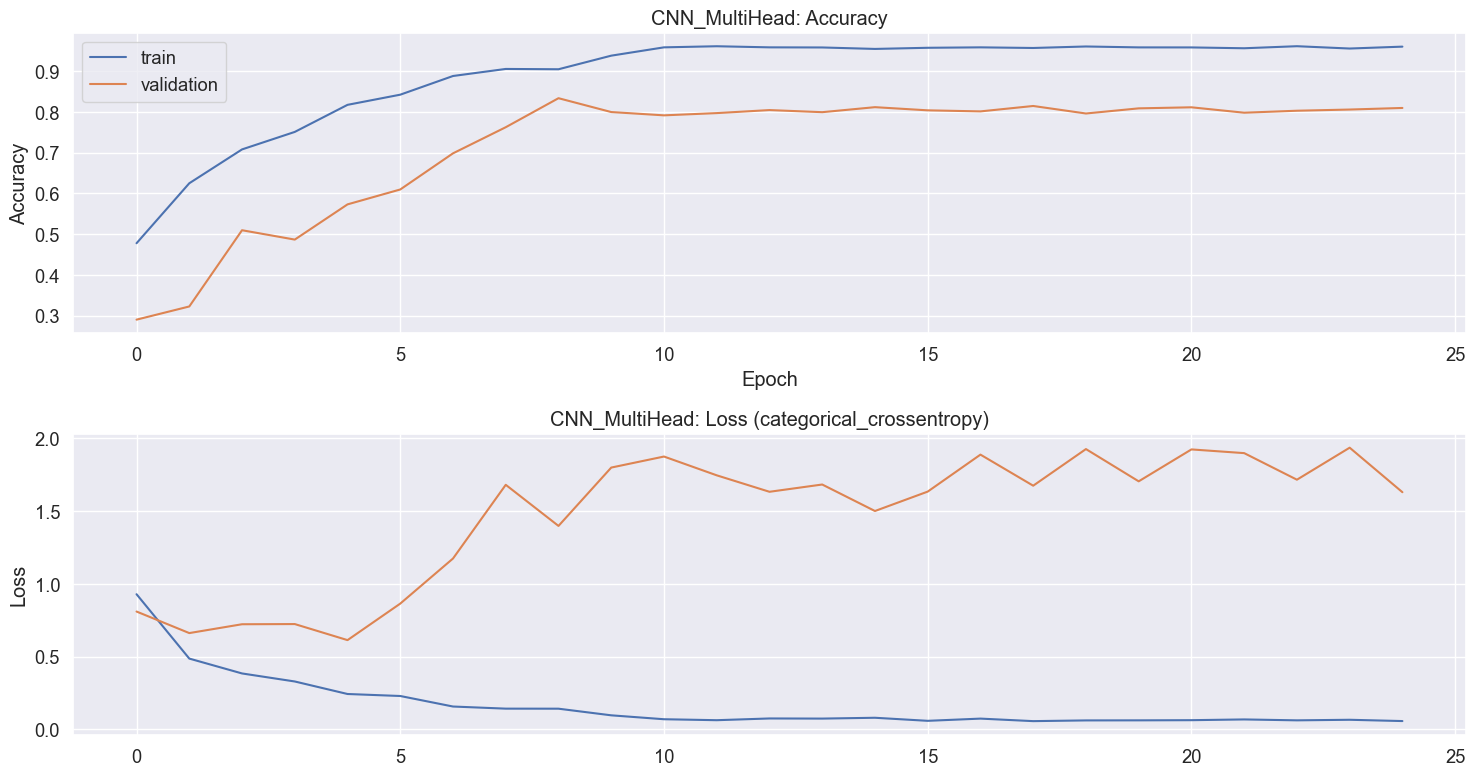

Training model : models/model_LSTM_stock_FET-USDT_lookback_24
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: LSTM
Epoch 1/200

Epoch 1: val_loss improved from inf to 0.85538, saving model to models\model_LSTM_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


646/646 - 38s - loss: 0.9303 - accuracy: 0.4617 - matthews_correlation_coefficient: 0.1162 - val_loss: 0.8554 - val_accuracy: 0.1046 - val_matthews_correlation_coefficient: -2.2529e-01 - lr: 0.0010 - 38s/epoch - 59ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.85538 to 0.78847, saving model to models\model_LSTM_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


646/646 - 31s - loss: 0.7570 - accuracy: 0.4527 - matthews_correlation_coefficient: 0.0805 - val_loss: 0.7885 - val_accuracy: 0.2995 - val_matthews_correlation_coefficient: -1.5312e-01 - lr: 0.0010 - 31s/epoch - 49ms/step
Epoch 3/200

Epoch 3: val_loss improved from 0.78847 to 0.76336, saving model to models\model_LSTM_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


...

646/646 - 31s - loss: 0.6227 - accuracy: 0.4777 - matthews_correlation_coefficient: 0.1368 - val_loss: 0.7634 - val_accuracy: 0.3008 - val_matthews_correlation_coefficient: -1.2810e-01 - lr: 0.0010 - 31s/epoch - 49ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 0.76336
646/646 - 24s - loss: 0.6742 - accuracy: 0.5259 - matthews_correlation_coefficient: 0.2444 - val_loss: 0.8769 - val_accuracy: 0.2600 - val_matthews_correlation_coefficient: -1.8329e-01 - lr: 0.0010 - 24s/epoch - 37ms/step
Epoch 5/200

Epoch 5: val_loss improved from 0.76336 to 0.70145, saving model to models\model_LSTM_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


646/646 - 34s - loss: 0.5408 - accuracy: 0.5046 - matthews_correlation_coefficient: 0.1926 - val_loss: 0.7015 - val_accuracy: 0.5382 - val_matthews_correlation_coefficient: 0.3147 - lr: 0.0010 - 34s/epoch - 52ms/step
Epoch 6/200

Epoch 6: val_loss did not improve from 0.70145
646/646 - 32s - loss: 0.4464 - accuracy: 0.6065 - matthews_correlation_coefficient: 0.3903 - val_loss: 0.9746 - val_accuracy: 0.4955 - val_matthews_correlation_coefficient: 0.2432 - lr: 0.0010 - 32s/epoch - 50ms/step
Epoch 7/200

Epoch 7: val_loss did not improve from 0.70145
646/646 - 29s - loss: 0.3874 - accuracy: 0.6771 - matthews_correlation_coefficient: 0.5084 - val_loss: 0.7052 - val_accuracy: 0.5654 - val_matthews_correlation_coefficient: 0.3481 - lr: 0.0010 - 29s/epoch - 45ms/step
Epoch 8/200

Epoch 8: val_loss did not improve from 0.70145
646/646 - 23s - loss: 0.3485 - accuracy: 0.7297 - matthews_correlation_coefficient: 0.5915 - val_loss: 1.2390 - val_accuracy: 0.4968 - val_matthews_correlation_coefficie

INFO:tensorflow:Assets written to: models\model_LSTM_stock_FET-USDT_lookback_24\assets


646/646 - 28s - loss: 0.3238 - accuracy: 0.7659 - matthews_correlation_coefficient: 0.6454 - val_loss: 0.6533 - val_accuracy: 0.6924 - val_matthews_correlation_coefficient: 0.5385 - lr: 0.0010 - 28s/epoch - 44ms/step
Epoch 11/200

Epoch 11: val_loss did not improve from 0.65326
646/646 - 28s - loss: 0.3359 - accuracy: 0.7388 - matthews_correlation_coefficient: 0.6056 - val_loss: 1.9078 - val_accuracy: 0.6833 - val_matthews_correlation_coefficient: 0.5249 - lr: 0.0010 - 28s/epoch - 43ms/step
Epoch 12/200

Epoch 12: val_loss did not improve from 0.65326
646/646 - 22s - loss: 0.2381 - accuracy: 0.8210 - matthews_correlation_coefficient: 0.7309 - val_loss: 3.7756 - val_accuracy: 0.8015 - val_matthews_correlation_coefficient: 0.7022 - lr: 0.0010 - 22s/epoch - 34ms/step
Epoch 13/200

Epoch 13: val_loss did not improve from 0.65326
646/646 - 20s - loss: 0.2638 - accuracy: 0.8206 - matthews_correlation_coefficient: 0.7306 - val_loss: 2.9097 - val_accuracy: 0.6823 - val_matthews_correlation_coe

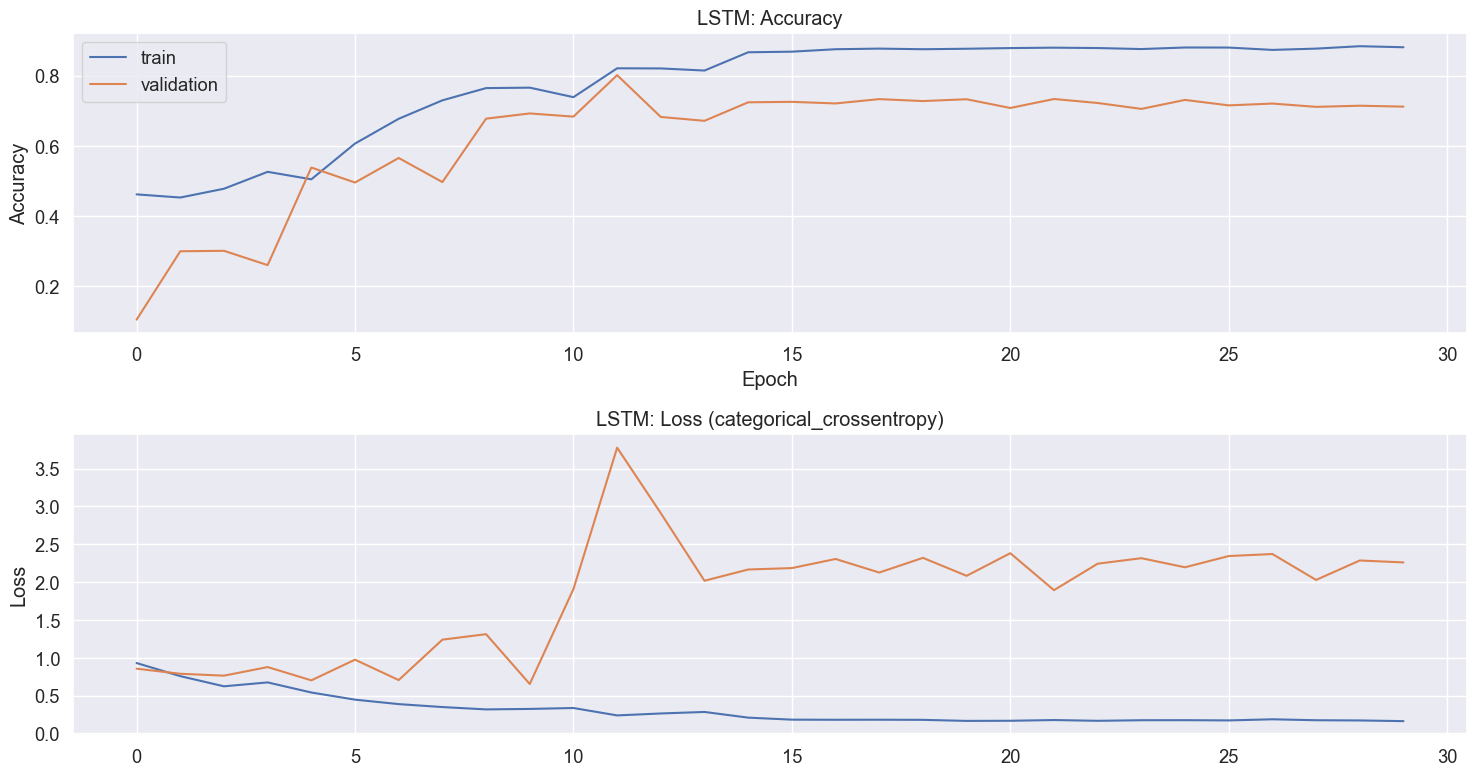

Training model : models/model_LSTM_AT_stock_FET-USDT_lookback_24
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: LSTM_AT
Epoch 1/200

Epoch 1: val_loss improved from inf to 4.09965, saving model to models\model_LSTM_AT_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


646/646 - 37s - loss: 4.4246 - accuracy: 0.5107 - matthews_correlation_coefficient: 0.2660 - val_loss: 4.0997 - val_accuracy: 0.4764 - val_matthews_correlation_coefficient: 0.2035 - lr: 0.0010 - 37s/epoch - 58ms/step
Epoch 2/200

Epoch 2: val_loss improved from 4.09965 to 3.84670, saving model to models\model_LSTM_AT_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


646/646 - 28s - loss: 2.1836 - accuracy: 0.5529 - matthews_correlation_coefficient: 0.3295 - val_loss: 3.8467 - val_accuracy: 0.4168 - val_matthews_correlation_coefficient: 0.1257 - lr: 0.0010 - 28s/epoch - 43ms/step
Epoch 3/200

Epoch 3: val_loss improved from 3.84670 to 2.63470, saving model to models\model_LSTM_AT_stock_FET-USDT_lookback_24
INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


...

646/646 - 35s - loss: 0.3449 - accuracy: 0.7867 - matthews_correlation_coefficient: 0.6802 - val_loss: 1.6016 - val_accuracy: 0.7160 - val_matthews_correlation_coefficient: 0.5726 - lr: 1.0000e-09 - 35s/epoch - 54ms/step
Epoch 26/200

Epoch 26: val_loss did not improve from 1.60161
646/646 - 17s - loss: 0.2829 - accuracy: 0.7949 - matthews_correlation_coefficient: 0.6930 - val_loss: 1.8780 - val_accuracy: 0.7063 - val_matthews_correlation_coefficient: 0.5547 - lr: 1.0000e-09 - 17s/epoch - 26ms/step
Epoch 27/200

Epoch 27: val_loss did not improve from 1.60161
646/646 - 16s - loss: 0.3057 - accuracy: 0.7967 - matthews_correlation_coefficient: 0.6939 - val_loss: 2.0345 - val_accuracy: 0.7076 - val_matthews_correlation_coefficient: 0.5571 - lr: 1.0000e-09 - 16s/epoch - 25ms/step
Epoch 28/200

Epoch 28: val_loss did not improve from 1.60161
646/646 - 16s - loss: 0.3059 - accuracy: 0.7868 - matthews_correlation_coefficient: 0.6805 - val_loss: 2.0803 - val_accuracy: 0.6911 - val_matthews_cor

INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


646/646 - 28s - loss: 0.3170 - accuracy: 0.7860 - matthews_correlation_coefficient: 0.6777 - val_loss: 1.5864 - val_accuracy: 0.7073 - val_matthews_correlation_coefficient: 0.5624 - lr: 1.0000e-09 - 28s/epoch - 43ms/step
Epoch 30/200

Epoch 30: val_loss did not improve from 1.58636
646/646 - 15s - loss: 0.3174 - accuracy: 0.7892 - matthews_correlation_coefficient: 0.6826 - val_loss: 1.8932 - val_accuracy: 0.6959 - val_matthews_correlation_coefficient: 0.5393 - lr: 1.0000e-09 - 15s/epoch - 23ms/step
Epoch 31/200

Epoch 31: val_loss did not improve from 1.58636
646/646 - 15s - loss: 0.3212 - accuracy: 0.7894 - matthews_correlation_coefficient: 0.6840 - val_loss: 2.0949 - val_accuracy: 0.6713 - val_matthews_correlation_coefficient: 0.5070 - lr: 1.0000e-09 - 15s/epoch - 23ms/step
Epoch 32/200

Epoch 32: val_loss did not improve from 1.58636
646/646 - 17s - loss: 0.3016 - accuracy: 0.7896 - matthews_correlation_coefficient: 0.6847 - val_loss: 2.0028 - val_accuracy: 0.6904 - val_matthews_cor

INFO:tensorflow:Assets written to: models\model_LSTM_AT_stock_FET-USDT_lookback_24\assets


646/646 - 34s - loss: 0.2850 - accuracy: 0.7978 - matthews_correlation_coefficient: 0.6952 - val_loss: 1.5758 - val_accuracy: 0.7063 - val_matthews_correlation_coefficient: 0.5582 - lr: 1.0000e-09 - 34s/epoch - 52ms/step
Epoch 34/200

Epoch 34: val_loss did not improve from 1.57581
646/646 - 21s - loss: 0.3136 - accuracy: 0.7838 - matthews_correlation_coefficient: 0.6734 - val_loss: 1.9710 - val_accuracy: 0.6982 - val_matthews_correlation_coefficient: 0.5427 - lr: 1.0000e-09 - 21s/epoch - 33ms/step
Epoch 35/200

Epoch 35: val_loss did not improve from 1.57581
646/646 - 22s - loss: 0.3129 - accuracy: 0.7890 - matthews_correlation_coefficient: 0.6821 - val_loss: 1.6996 - val_accuracy: 0.6979 - val_matthews_correlation_coefficient: 0.5420 - lr: 1.0000e-09 - 22s/epoch - 33ms/step
Epoch 36/200

Epoch 36: val_loss did not improve from 1.57581
646/646 - 17s - loss: 0.2972 - accuracy: 0.7925 - matthews_correlation_coefficient: 0.6883 - val_loss: 1.9230 - val_accuracy: 0.6907 - val_matthews_cor

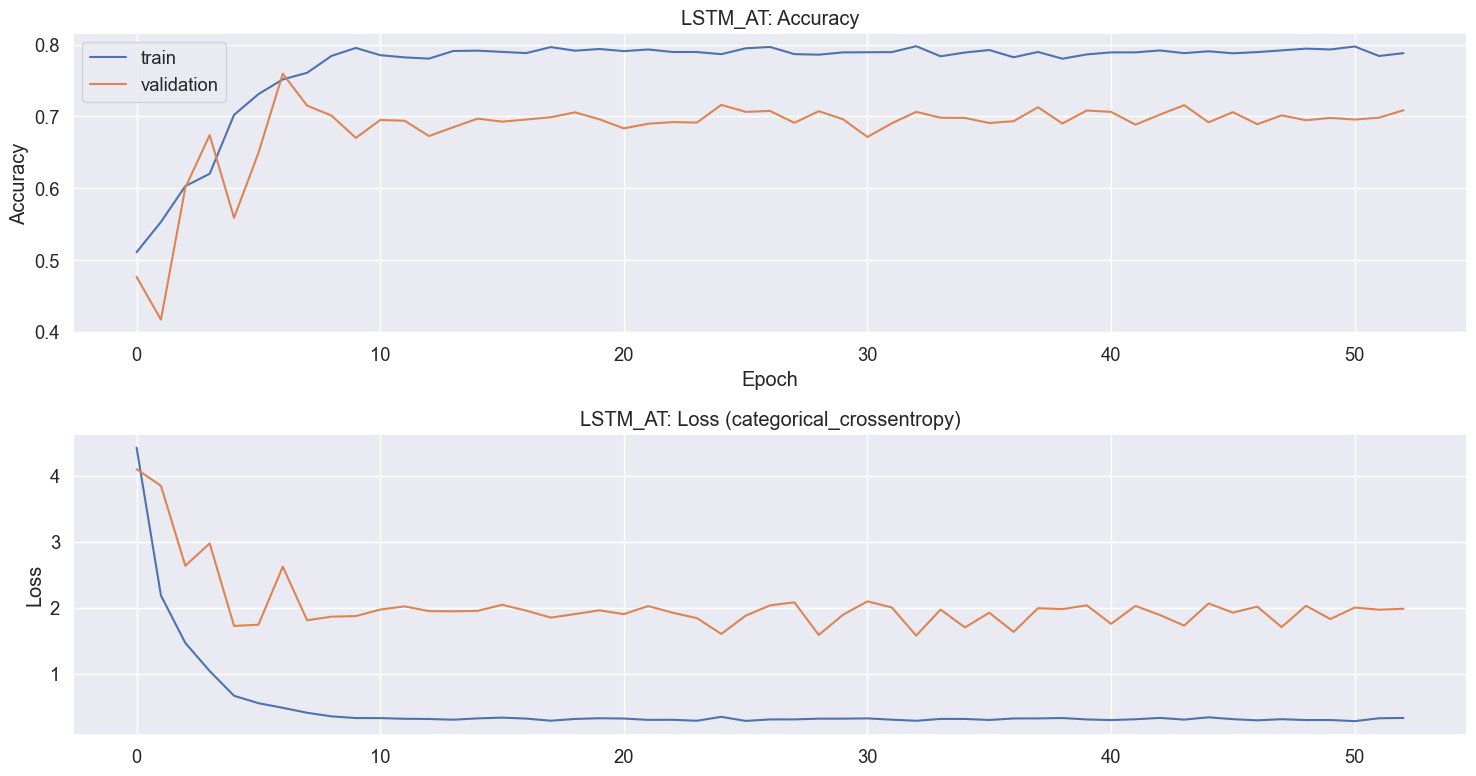

In [216]:
list_of_models=[model_MLP, model_GRU, model_CNN_LSTM, model_CNN_MultiHead, model_LSTM, model_LSTM_AT]
#list_of_models=[model_LSTM, model_LSTM_AT, model_GRU ]
#list_of_models=[model_LSTM_AT]
#list_of_models=[model_MLP, model_CNN_LSTM, model_LSTM_AT]
#list_of_models=[model_CNN_MultiHead]

for model in list_of_models:  
    optimizer = get_optimizer()
    csvLogger, model_checkpoint_callback  = checkpoints(model._name)
    model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])

    print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
    print(f'Initing train fo model: {model._name}')
    #history=model.fit( X_data_gen_train, validation_data=X_data_gen_val, epochs=200, batch_size=32, shuffle=False, validation_split=0.3, callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback,csvLogger])
    #history=model.fit_generator( X_data_gen_train, epochs=200, callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback,csvLogger], validation_data=X_data_gen_val, verbose=0)
    #history=model.fit( X_data_gen_train.features, X_data_gen_train.y_classification, epochs=200, verbose=1)
    history = model.fit(
        X_data_gen_train,
        epochs=200,
        callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
        validation_data=X_data_gen_val,
        #shuffle=True,
        verbose=2
    )
    # Assuming history_metric, history_metric_val, history are defined elsewhere

    fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

    # Plot accuracy, sharing x-axis with NRMSE
    axes[0].plot(history.history['accuracy'])
    axes[0].plot(history.history['val_accuracy'])
    axes[0].set_title(f'{model._name}: Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')  # Shared x-axis label
    axes[0].legend(['train', 'validation'], loc='upper left')

    # Plot loss
    axes[1].plot(history.history['loss'])
    axes[1].plot(history.history['val_loss'])
    axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
    axes[1].set_ylabel('Loss')

    # Adjust spacing and margins (optional)
    plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

    # Fine-tune spacing (optional)
    plt.tight_layout()

    plt.show()

    #history=model.fit( x=X_train, y=y_train, epochs=200, batch_size=256, shuffle=True, validation_split=0.1, callbacks=[EarlyStopping,model_checkpoint_callback, reduceLr])

### Validation

#### Load the trained models


In [217]:
trained_best_models={}
for model in list_of_models:
    print(model.name)
    checkpoint_filepath =f'models/model_{model._name}_stock_{ticker}_lookback_{lookback}'
    trained_best_models[f'{model._name}']=tf.keras.models.load_model(
        checkpoint_filepath, 
        custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient})

MLP
GRU
CNN_LSTM_MultiHead
CNN_MultiHead
LSTM
LSTM_AT


#### Using the validation Dataset

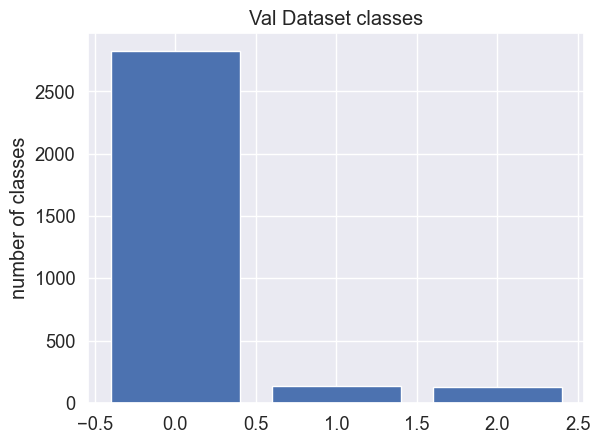

In [218]:
Y_val_categorical=np.argmax(X_data_gen_val.y_classification,axis=1)
classes, counts=np.unique(Y_val_categorical,return_counts=True) 

fig, ax = plt.subplots()
plt.bar(classes,counts)
ax.set_ylabel('number of classes')
ax.set_title('Val Dataset classes')
plt.show()

In [219]:
X_data_gen_val = FeaturesDataGenerator(df[df['Date'].isin(T_val)].iloc[:,1:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False)


self.pred_days 15
input data shape (3089, 24, 24)
output data shape (3089, 3)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide



In [220]:
# get metrics on validation dataset
idxs=np.where(np.argmax(X_data_gen_val.y_classification, axis=1)> -1 )[0]

x_data = np.zeros_like(X_data_gen_val.features)
for i in range(X_data_gen_val.features.shape[0]):
    x_data[i] = X_data_gen_val.norm_minmax(
        X_data_gen_val.features[i],
        minimum=min_norm,
        maximum=max_norm,
        axis=0
    )

import utils
for model_name in trained_best_models:

    label_pred = trained_best_models[model_name].predict(x_data)
    print(model_name,' classification Accuracy',
                    utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                    np.argmax(label_pred,axis=1), average='micro'))
#utils.model_metrics(['subida','Descida'], y_test, y_pred, Get_metrics=False)

#utils.plot_confusion_matrix(['subida','Descida'], y_test, y_pred)

97/97 [==============================] - 1s 6ms/step
MLP  classification Accuracy 0.7552606021366138
97/97 [==============================] - 2s 8ms/step
GRU  classification Accuracy 0.5979281320815798
97/97 [==============================] - 1s 7ms/step
CNN_LSTM_MultiHead  classification Accuracy 0.47588216251213983
97/97 [==============================] - 2s 12ms/step
CNN_MultiHead  classification Accuracy 0.691485917772742
97/97 [==============================] - 2s 14ms/step
LSTM  classification Accuracy 0.7063774684363872
97/97 [==============================] - 2s 10ms/step
LSTM_AT  classification Accuracy 0.7652962123664616


In [221]:
np.argmax(X_data_gen_val.y_classification[idxs],axis=1).shape

(3089,)

In [240]:
np.apply_along_axis(lambda row: row.shape, axis=1, arr=X_data_gen_val.features[idxs])

array([[[24, 24, 24, ..., 24, 24, 24]],

       [[24, 24, 24, ..., 24, 24, 24]],

       [[24, 24, 24, ..., 24, 24, 24]],

       ...,

       [[24, 24, 24, ..., 24, 24, 24]],

       [[24, 24, 24, ..., 24, 24, 24]],

       [[24, 24, 24, ..., 24, 24, 24]]])

In [ ]:
np.zeros_like

In [248]:
def apply_NomrMinmax(features, minimum= min_norm, maximum= max_norm, axis=0):
    norm_features=np.zeros_like(features)
    for idx in range(len(features)):
        norm_features[idx]=X_data_gen_val.norm_minmax(features[idx], minimum, maximum, axis)
    return norm_features

Model name: CNN_MultiHead
97/97 [==============================] - 1s 7ms/step
CNN_MultiHead  classification Accuracy 0.691485917772742


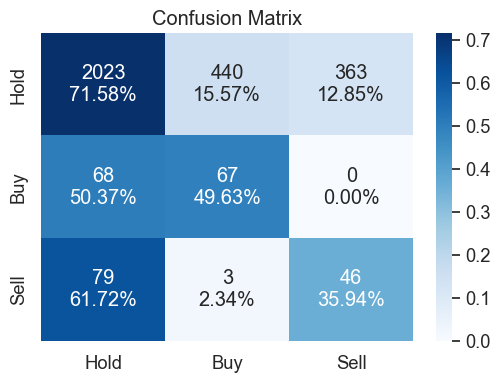

In [ ]:
model_name = "CNN_MultiHead"  
print('Model name:',model_name)

x_data= X_data_gen_val.apply_NomrMinmax(X_data_gen_val.features[idxs], minimum= min_norm, maximum= max_norm, axis=0)

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification[idxs],axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification[idxs],axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

### Using test dataset

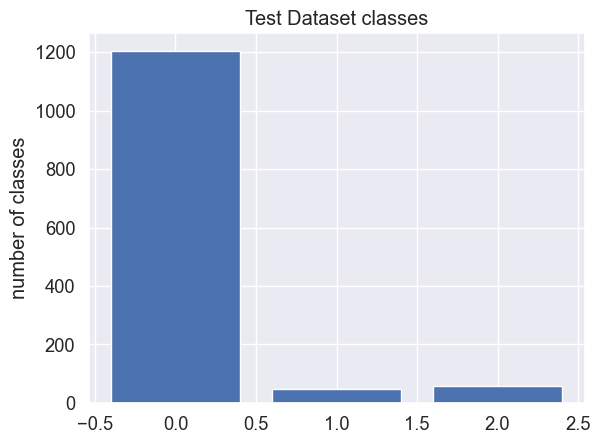

In [223]:
Y_train_categorical=np.argmax(X_data_gen_test.y_classification,axis=1)
classes, counts=np.unique(Y_train_categorical,return_counts=True) 

fig, ax = plt.subplots()
plt.bar(classes,counts)
ax.set_ylabel('number of classes')
ax.set_title('Test Dataset classes')
plt.show()

In [224]:
X_data_gen_test = FeaturesDataGenerator(df[df['Date'].isin(T_test)].iloc[:,1:], lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False)
test_data=[]
targets=[]
for X,y in X_data_gen_test:
    #train_data+=[scaler.transform(np.array(X).reshape(-1,1))]
    test_data+=[np.array(X)]
    targets+=[np.argmax(y)]
targets = np.stack(targets)
test_data = np.vstack(test_data)

self.pred_days 15


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



input data shape (1311, 24, 24)
output data shape (1311, 3)


In [225]:
label_pred.shape

(3089, 3)

In [226]:
# get metrics for all deep learning models 
import utils
for model_name in trained_best_models:
    label_pred = trained_best_models[model_name].predict(test_data)
    print(f'{model_name} metrics:')
    utils.model_average_std_metrics(targets, np.argmax(label_pred,axis=1), Get_metrics= True,  Verbose=True) ;
    print('------------------------------------------------')

41/41 [==============================] - 0s 3ms/step
MLP metrics:
Precision Score: 0.445±0.3547
Recall Score: 0.3998±0.3395
F1-Score: 0.3578±0.375
Accuracy: 0.3998±0.3395
------------------------------------------------
41/41 [==============================] - 0s 6ms/step
GRU metrics:
Precision Score: 0.5038±0.3047
Recall Score: 0.3858±0.4168
F1-Score: 0.4032±0.3862
Accuracy: 0.3858±0.4168
------------------------------------------------
41/41 [==============================] - 0s 5ms/step
CNN_LSTM_MultiHead metrics:
Precision Score: 0.352±0.4077
Recall Score: 0.4489±0.2992
F1-Score: 0.2534±0.2233
Accuracy: 0.4489±0.2992
------------------------------------------------
41/41 [==============================] - 0s 8ms/step
CNN_MultiHead metrics:
Precision Score: 0.44±0.3432
Recall Score: 0.3887±0.4118
F1-Score: 0.4004±0.3878
Accuracy: 0.3887±0.4118
------------------------------------------------
41/41 [==============================] - 1s 13ms/step
LSTM metrics:
Precision Score: nan±nan

d:\Projetos_python\Time_Series_Forecast\acoes\utils.py:97: RuntimeWarning:

invalid value encountered in divide



41/41 [==============================] - 1s 12ms/step
LSTM_AT metrics:
Precision Score: nan±nan
Recall Score: 0.3389±0.4502
F1-Score: nan±nan
Accuracy: 0.3389±0.4502
------------------------------------------------


d:\Projetos_python\Time_Series_Forecast\acoes\utils.py:97: RuntimeWarning:

invalid value encountered in divide



Model name: CNN_MultiHead
41/41 [==============================] - 0s 7ms/step
CNN_MultiHead  classification Accuracy 0.4003627888123227


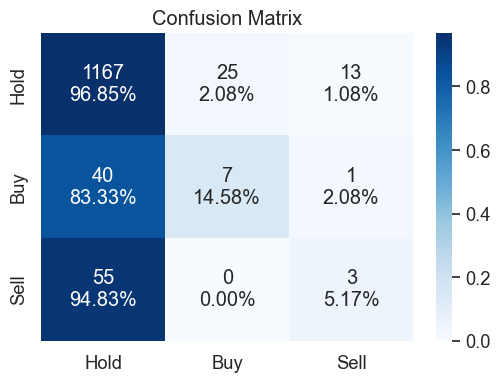

In [227]:
model_name = "CNN_MultiHead"  
print('Model name:',model_name)

label_pred = trained_best_models[model_name].predict(test_data)
print(model_name,' classification Accuracy',utils.f1_score(targets, np.argmax(label_pred,axis=1),average='macro'))

cf_matrix = utils.confusion_matrix(targets,np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

Model name: MLP


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



41/41 [==============================] - 0s 6ms/step
MLP  classification Accuracy 0.7459954233409611
Model name: GRU


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



41/41 [==============================] - 1s 10ms/step
GRU  classification Accuracy 0.5728451563691839
Model name: CNN_LSTM_MultiHead


...

41/41 [==============================] - 1s 11ms/step
CNN_MultiHead  classification Accuracy 0.7124332570556827
Model name: LSTM
 1/41 [..............................] - ETA: 1s

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



41/41 [==============================] - 1s 16ms/step
LSTM  classification Accuracy 0.7452326468344777
Model name: LSTM_AT


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



41/41 [==============================] - 1s 12ms/step
LSTM_AT  classification Accuracy 0.7726926010678871


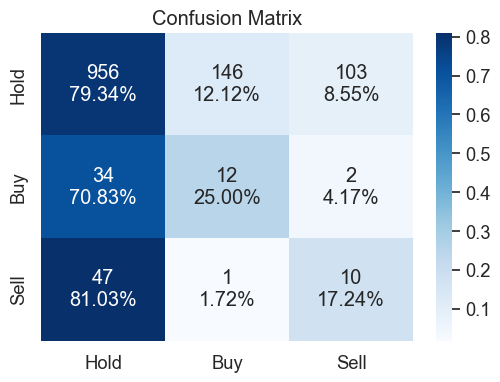

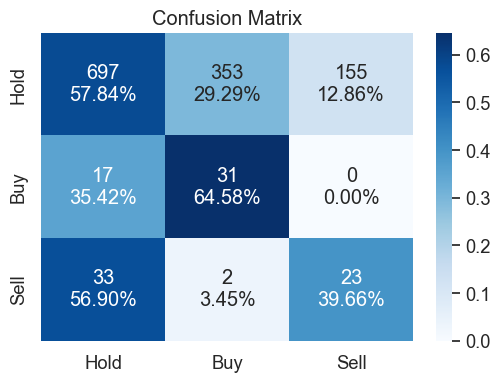

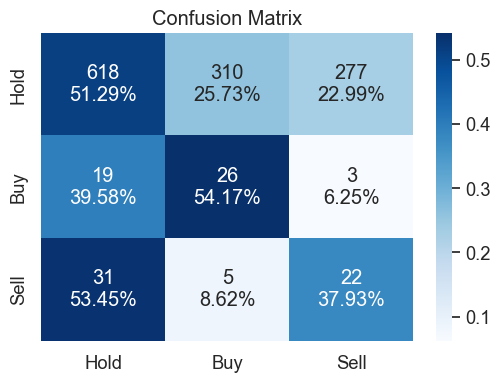

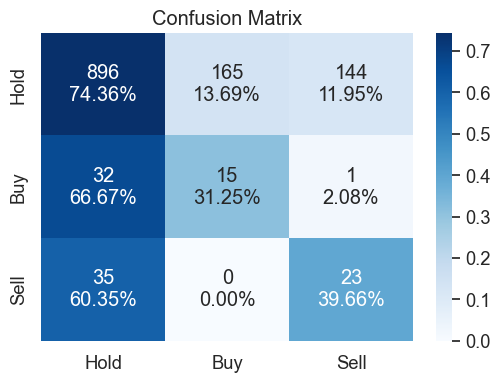

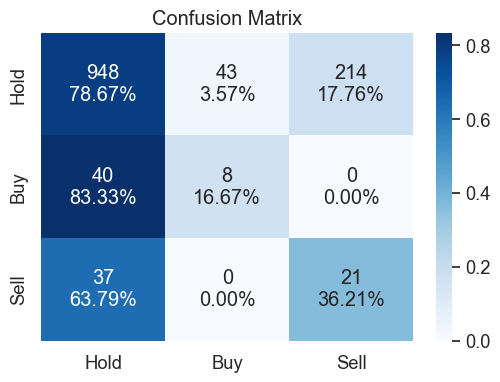

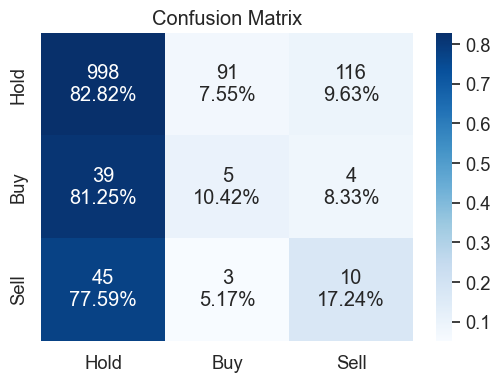

In [ ]:
model_name = "CNN_MultiHead"    
for model_name in list_of_models:
    model_name = model_name._name
    print('Model name:',model_name)

    x_data= X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, minimum= min_norm, maximum= max_norm, axis=0)

    label_pred = trained_best_models[model_name].predict(x_data)
    print(model_name,' classification Accuracy',
                    utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                    np.argmax(label_pred,axis=1),average="micro"))

    cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
    
    try:
        utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
    except:
        print(cf_matrix)

In [229]:
model_name

'LSTM_AT'

#### Using Machine Learning models to Predicti next recomendations

In [230]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score
import h5py

import joblib

# Define ML models and their names
ML_models = {
    'SVM': SVC(kernel='rbf',decision_function_shape='ovr'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=300),
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost RF': xgb.XGBRFClassifier(n_estimators=300)
}

x_data_train= np.vstack(np.apply_along_axis(lambda row: X_data_gen_train.norm_minmax(row, minimum= min_norm, maximum= max_norm, axis=-1), axis=1, arr=X_data_gen_train.features).T).T
x_data_val= np.vstack(np.apply_along_axis(lambda row: X_data_gen_val.norm_minmax(row, minimum= min_norm, maximum= max_norm, axis=-1), axis=1, arr=X_data_gen_val.features).T).T
x_data_test= np.vstack(np.apply_along_axis(lambda row: X_data_gen_test.norm_minmax(row, minimum= min_norm, maximum= max_norm, axis=-1), axis=1, arr=X_data_gen_test.features).T).T


# Iterate over ML models
for name, model in ML_models.items():
    # Train the model
    model.fit(x_data_train, np.argmax(X_data_gen_train.y_classification, axis=1) )

    # Make predictions on datasets
    train_pred = model.predict(x_data_train)
    val_pred = model.predict(x_data_val)
    test_pred = model.predict(x_data_test)

    # Calculate accuracy on datasets
    train_accuracy = accuracy_score(np.argmax(X_data_gen_train.y_classification, axis=1), train_pred)
    val_accuracy = accuracy_score(np.argmax(X_data_gen_val.y_classification, axis=1), val_pred)
    #test_accuracy = accuracy_score(np.argmax(X_data_gen_test.comput_outputs(df[df['Date'].isin(T_test)].iloc[:,1].values), axis=1), test_pred)
    test_accuracy = accuracy_score(np.argmax(X_data_gen_test.y_classification, axis=1), test_pred)

    # Print results
    print('-------------------------------------------------------------')
    print(f'{name} - Train Classification Accuracy: {train_accuracy}')
    print(f'{name} - Validation Classification Accuracy: {val_accuracy}')
    print(f'{name} - Test Classification Accuracy: {test_accuracy}')

    # Salve o modelo
    #joblib.dump(model, f'models/model_{name}_stock_{ticker}_lookback_{lookback}.joblib')

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Model name: Decision Tree
Decision Tree  classification Accuracy 0.35409994408011797


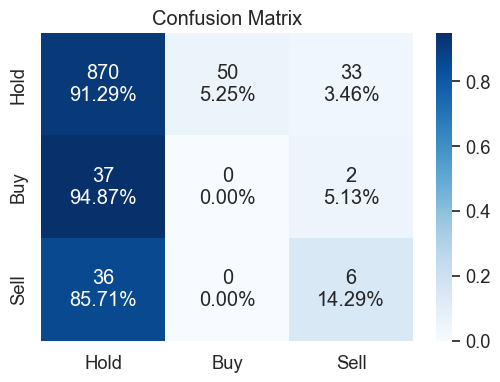

In [ ]:
model_name = "Decision Tree"  
print('Model name:',model_name)

label_pred = ML_models[model_name].predict(np.vstack(test_data.T).T)

print(model_name,' classification Accuracy',utils.f1_score(targets, label_pred, average='macro'))

cf_matrix = utils.confusion_matrix(targets,label_pred)
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

### Get new values to future prediction 

In [ ]:
dias_antes=1
n_steps=7

print("Temos dados até o dia :",T_test.iloc[-1].date())

print("Estamos Fornecendo dados até o dia :",T_test.iloc[-1].date() -datetime.timedelta(days=dias_antes))

print("O modelo fará previsões até o dia: ",T_test.iloc[-1].date() -datetime.timedelta(days=dias_antes) + datetime.timedelta(days=n_steps))

Temos dados até o dia : 2024-12-19
Estamos Fornecendo dados até o dia : 2024-12-18
O modelo fará previsões até o dia:  2024-12-25


In [ ]:
data_inference=df[df['Date'].isin(T_test.iloc[-lookback-3:])].iloc[:,1:]
#data_inference=df[df['Date'].isin(T_test.iloc[:])].iloc[:,1:]
data_inference.shape


(27, 11)

In [ ]:
data_inference.shape

(27, 11)

In [ ]:
dataGen_inference = FeaturesDataGenerator(data_inference, lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False)

self.pred_days 15
input data shape (3, 24, 25)
output data shape (3, 3)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:329: RuntimeWarning:

divide by zero encountered in divide



In [ ]:
trade=['Hold','Buy','Sell']

In [ ]:
data_inference=df[df['Date'].isin(T_test.iloc[-lookback-pred_days:])].iloc[:,1:]
data_inference=df[df['Date'].isin(T_test.iloc[:-8])].iloc[:,1:]
data_inference['Close'].values.astype(np.float32).shape

(1050,)

In [ ]:
x_data_inference=dataGen_inference.comput_features(data_inference, pred_days=0)
x_data_inference.shape

(1026, 24, 25)

In [ ]:
x_data_inference=dataGen_inference.comput_features(data_inference, pred_days=0)
x_data= np.apply_along_axis(lambda row: X_data_gen_test.norm_minmax(row, minimum= min_norm, maximum= max_norm, axis=0), axis=1, arr=x_data_inference)

model_name='CNN_MultiHead'
label_pred = trained_best_models[model_name].predict(x_data)
trade[np.argmax(label_pred[-1])]

33/33 [==============================] - 0s 6ms/step


'Buy'

In [ ]:
model_name = "XGBoost RF"  
print('Model name:',model_name)
label_pred = ML_models[model_name].predict(np.vstack(x_data.T).T)
trade[np.argmax(label_pred[-1])]

Model name: XGBoost RF


'Hold'

In [ ]:
np.unique(label_pred, return_counts=True)

(array([0], dtype=int64), array([1026], dtype=int64))

### Inference in real time data 

In [ ]:
from datetime import datetime, timedelta
data_atual = datetime.now()
data_atual_formatada = data_atual.strftime('%Y-%m-%d')
dia_anterior = (data_atual - timedelta(days=11)).strftime('%Y-%m-%d')

interval ='4h'

# Baixar e consolidar dados em um DataFrame
cryptos_df = pd.DataFrame()
for crypto in cryptos:
    data = get_binance_data(crypto, start_time=dia_anterior, interval=interval)
    # Ajusta o nome da coluna removendo "USDT" antes de adicionar ao DF
    #data.columns = [crypto.replace('USDT', '')]
    if cryptos_df.empty:
        cryptos_df = data
    else:
        cryptos_df = pd.concat([cryptos_df, data], axis=1)

if not cryptos_df.empty:
    cryptos_df = cryptos_df.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume',
    })
    # Visualização dos dados
    cryptos_df=cryptos_df.rename_axis('Date')
    print(cryptos_df.shape)
else:
    print("Nenhum dado encontrado para o símbolo e intervalo especificados.")

cryptos_df.reset_index(inplace= True)

(69, 11)


In [ ]:
dataGen_inference = FeaturesDataGenerator(data_inference, lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False)
x_data_inference=dataGen_inference.comput_features(cryptos_df, pred_days=0)
x_data_inference.shape

self.pred_days 15
input data shape (1026, 24, 25)
output data shape (1026, 3)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:329: RuntimeWarning:

divide by zero encountered in divide



(45, 24, 25)

In [ ]:
x_data= np.apply_along_axis(lambda row: X_data_gen_test.norm_minmax(row, minimum= min_norm, maximum= max_norm, axis=0), axis=1, arr=x_data_inference)
model_name='CNN_MultiHead'
label_pred = trained_best_models[model_name].predict(x_data)
trade[np.argmax(label_pred[-1])]

2/2 [==============================] - 0s 16ms/step


'Hold'

In [ ]:
np.argmax(label_pred[:],axis=1)

array([2, 2, 2, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 2, 2,
       2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0], dtype=int64)

In [ ]:
model_name = "XGBoost RF"  
print('Model name:',model_name)
label_pred_ml = ML_models[model_name].predict(np.vstack(x_data.T).T)
trade[label_pred_ml[-1]]

Model name: XGBoost RF


'Hold'

In [ ]:
label_pred_ml

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0], dtype=int64)

In [ ]:
# Dados de exemplo
try:
    data_idx= -x_data_inference.shape[0]
    input_data = cryptos_df['Close'].iloc[data_idx:].values
    date = cryptos_df['Date'].iloc[data_idx:]
    #labels = labelling_method(close_price_list, 60)

    #labels=[trade[label] for label in label_pred_ml]
    labels=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
    

    labels=labels[data_idx:]
    print(np.unique(labels, return_counts=True))
    portfolio_values = backtest(input_data, labels, initial_capital=100000)

    # Gráfico do desempenho
    import plotly.graph_objects as go

    #fig = go.Figure()

    fig = go.Figure(data=[go.Candlestick(x=cryptos_df['Date'].iloc[data_idx:],
                    open=cryptos_df['Open'].iloc[data_idx:],
                    high=cryptos_df['High'].iloc[data_idx:],
                    low=cryptos_df['Low'].iloc[data_idx:],
                    close=cryptos_df['Close'].iloc[data_idx:],
                    name='Candlestick')])

    # Valor do portfólio
    #fig.add_trace(go.Scatter(
    #    x=X_data_gen_test.InputData['Date'],
    #    y=portfolio_values,
    #    mode='lines',
    #    name='Valor do Portfólio'
    #))

    # Configuração do layout
    fig.update_layout(
        title="Backtest de Estratégia de BUY, SELL, HOLD",
        xaxis_title="Data",
        yaxis_title="Valor",
        showlegend=False,
        width=1700,
        height=600,
        margin=dict(l=50, r=50, t=50, b=50)  # Margem esquerda, direita, superior e inferior
    )


    # Adiciona os marcadores BUY, SELL e HOLD
    for i, label in enumerate(labels):
        if label == "Buy":
            fig.add_trace(go.Scatter(
                x=[date.iloc[i]],
                y=[input_data[i] - 0.01*input_data[i]],
                mode='markers',
                marker=dict(color='green', size=10, symbol='triangle-up'),
                name='BUY'
            ))
        elif label == "Sell":
            fig.add_trace(go.Scatter(
                x=[date.iloc[i]],
                y=[input_data[i] + 0.01*input_data[i]],
                mode='markers',
                marker=dict(color='red', size=10, symbol='triangle-down'),
                name='SELL'
            ))
    fig.update_layout(xaxis_rangeslider_visible=False)
    fig.show()
except Exception as e:\
    print("Erro ao executar o código:", str(e))

(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([17, 20,  8], dtype=int64))
